In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")

print(df.shape)
print(df.columns)
df.head()

In [ ]:
import pandas as pd
import numpy as np

# Load your data
df = pd.read_csv('data.csv')

print("="*70)
print("PHASE 1: DATASET UNDERSTANDING - DATA QUALITY CHECK")
print("="*70)

# ============================================================
# CHECK 1: Basic Information
# ============================================================
print("\n[CHECK 1] BASIC INFORMATION")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Column names: {df.columns.tolist()}")

# ============================================================
# CHECK 2: Data Types
# ============================================================
print("\n[CHECK 2] DATA TYPES")
print(df.dtypes)

# ============================================================
# CHECK 3: Missing Values
# ============================================================
print("\n[CHECK 3] MISSING VALUES")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values - Dataset is CLEAN")
else:
    print("Missing values found:")
    print(missing)

# ============================================================
# CHECK 4: First 5 rows
# ============================================================
print("\n[CHECK 4] FIRST 5 ROWS")
print(df.head())

# ============================================================
# CHECK 5: Acceleration Statistics
# ============================================================
print("\n[CHECK 5] ACCELERATION (Vibration Signal) STATISTICS")
print(df['Acceleration'].describe())

# ============================================================
# CHECK 6: Fault Distribution (Class Balance)
# ============================================================
print("\n[CHECK 6] FAULT CLASS DISTRIBUTION")
fault_counts = df['Fault'].value_counts()
for fault, count in fault_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {fault:5s}: {count:,} readings ({percentage:5.1f}%)")

# ============================================================
# CHECK 7: Recording Distribution
# ============================================================
print("\n[CHECK 7] RECORDING DISTRIBUTION (by Data_No)")
recordings = df.groupby('Data_No').size()
print(f"Number of unique recordings: {len(recordings)}")
print(f"Readings per recording (should be 15,625):")
print(f"  Min: {recordings.min():,}")
print(f"  Max: {recordings.max():,}")
print(f"  Mean: {recordings.mean():.0f}")

# ============================================================
# CHECK 8: Bearing Types
# ============================================================
print("\n[CHECK 8] BEARING TYPES")
bearing_counts = df['Bearing+Rig'].value_counts()
for bearing, count in bearing_counts.items():
    print(f"  {bearing}: {count:,} readings")

# ============================================================
# CHECK 9: Operating Conditions
# ============================================================
print("\n[CHECK 9] OPERATING CONDITIONS")
print(f"Unique speeds (Speed_Set): {sorted(df['Speed_Set'].unique())}")
print(f"Unique forces: {sorted(df['Force'].unique())}")

# ============================================================
# CHECK 10: Time Column
# ============================================================
print("\n[CHECK 10] TIME SAMPLING")
# Check sampling interval
first_recording = df[df['Data_No'] == 1]
time_diff = np.diff(first_recording['Time'].values)
sampling_interval = time_diff[0]
sampling_frequency = 1 / sampling_interval

print(f"First recording time span: {first_recording['Time'].min():.6f} to {first_recording['Time'].max():.6f} seconds")
print(f"Sampling interval: {sampling_interval:.6f} seconds")
print(f"Sampling frequency: {sampling_frequency:.0f} Hz")

print("\n" + "="*70)
print("QUALITY CHECK COMPLETE")
print("="*70)

In [ ]:

# ─── PCA ON A TOY DATASET ─────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Create a 2D dataset with correlated features
# Like your std and RMS — both measure energy, so they move together
np.random.seed(42)
n = 200

# Feature 1: energy level (think: RMS)
energy = np.random.normal(0, 1, n)

# Feature 2: strongly correlated with energy (think: std ≈ RMS)
std_like = energy * 0.9 + np.random.normal(0, 0.2, n)

# Feature 3: independent (think: kurtosis — different physics)
kurtosis_like = np.random.normal(0, 1, n)

X = np.column_stack([energy, std_like, kurtosis_like])
X_df = pd.DataFrame(X, columns=['rms', 'std', 'kurtosis'])

# STEP 1: Scale features FIRST — PCA is sensitive to scale
# Without scaling: kurtosis (0–172) dominates std (0–0.5)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)  # each feature: mean=0, std=1

# STEP 2: Apply PCA
# n_components=None keeps all components — good for exploration
pca = PCA(n_components=None)
X_pca = pca.fit_transform(X_scaled)

# STEP 3: Inspect results
print("Explained variance ratio:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.3f} ({ev*100:.1f}%)")

# PC1: ~0.65 (captures the correlated rms+std axis)
# PC2: ~0.22 (captures kurtosis — independent of PC1)
# PC3: ~0.13 (noise)

print("\nPC1 loadings (coefficients on original features):")
for feat, loading in zip(['rms', 'std', 'kurtosis'], pca.components_[0]):
    print(f"  {feat}: {loading:.3f}")

# Loadings: how much each original feature contributes to this PC
# rms: 0.71, std: 0.71, kurtosis: 0.0 ← captures the correlated pair!

print("\nCumulative variance explained:")
cumvar = np.cumsum(pca.explained_variance_ratio_)
for i, cv in enumerate(cumvar):
    print(f"  {i+1} components: {cv:.3f} ({cv*100:.1f}%)")


In [ ]:

# ─── PCA ON YOUR BEARING FEATURES ────────────────────────────────

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Assume: features_df = your 300×9 feature matrix from Phase 3
# columns: mean, std, variance, rms, peak, peak_to_peak,
#          crest_factor, kurtosis, skewness
# labels:  fault_labels (OK, IR, OR, RE)

features_df = None
df_phase3 = pd.read_csv('bearing_features_phase3.csv')
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']
features_df = df_phase3[feature_cols]
fault_labels = df_phase3['fault']

X = features_df.values          # shape: (300, 9)
fault_labels = None
y = fault_labels.values          # shape: (300,)

# ── Option A: PCA for exploration (how redundant are our features?) ─

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

print("Variance explained per component:")
for i, (ev, cv) in enumerate(zip(
        pca_full.explained_variance_ratio_,
        np.cumsum(pca_full.explained_variance_ratio_))):
    bar = '█' * int(ev * 50)
    print(f"  PC{i+1}: {bar} {ev:.3f}  cumulative: {cv:.3f}")

# Expected for your features:
# PC1: ~0.40 (energy: std+rms+variance)
# PC2: ~0.25 (spikiness: kurtosis+crest)
# PC3: ~0.15 (amplitude: peak+p2p)
# 3 components ≈ 80% of total variance

# ── Option B: PCA + RF pipeline (does PCA help?) ──────────────────

# Without PCA (your Phase 4 baseline)
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_no_pca = cross_val_score(pipe_no_pca, X, y, cv=5, scoring='accuracy')
print(f"RF without PCA: {cv_no_pca.mean():.4f} ± {cv_no_pca.std():.4f}")

# With PCA (keep 95% variance, discard rest)
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # auto-select k for 95% variance
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_pca = cross_val_score(pipe_pca, X, y, cv=5, scoring='accuracy')
print(f"RF with PCA:    {cv_pca.mean():.4f} ± {cv_pca.std():.4f}")

# KEY QUESTION: does PCA help Random Forest?
# Probably NOT much — RF already handles correlated features via
# random feature subsets. PCA may HURT by destroying interpretability.
# PCA helps most for: SVM, KNN, logistic regression, distance-based models

# ── Option C: Check loadings — what does each PC represent? ───────

pca_3 = PCA(n_components=3)
pca_3.fit(X_scaled)

feat_names = ['mean','std','variance','rms','peak','peak_to_peak',
              'crest_factor','kurtosis','skewness']

print("\nPC loadings (what each PC is made of):")
for pc_idx, pc in enumerate(pca_3.components_):
    print(f"\nPC{pc_idx+1}:")
    for name, loading in sorted(zip(feat_names, pc),
                                  key=lambda x: abs(x[1]), reverse=True):
        bar = '█' * int(abs(loading) * 20)
        print(f"  {name:15s}: {bar} {loading:+.3f}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('data.csv')

print("="*70)
print("PHASE 2: SIGNAL UNDERSTANDING - VIBRATION WAVEFORM ANALYSIS")
print("="*70)

# ============================================================
# STEP 1: Extract one complete recording of each fault type
# ============================================================

print("\n[STEP 1] Extracting one complete recording per fault type...")

# Get one recording (all 15,625 readings) for each fault type
ok_recording = df[df['Fault'] == 'OK'].groupby('Data_No').first().reset_index()
ok_data_no = ok_recording['Data_No'].iloc[0]
ok_signal = df[df['Data_No'] == ok_data_no]['Acceleration'].values
ok_time = df[df['Data_No'] == ok_data_no]['Time'].values

ir_recording = df[df['Fault'] == 'IR'].groupby('Data_No').first().reset_index()
ir_data_no = ir_recording['Data_No'].iloc[0]
ir_signal = df[df['Data_No'] == ir_data_no]['Acceleration'].values
ir_time = df[df['Data_No'] == ir_data_no]['Time'].values

or_recording = df[df['Fault'] == 'OR'].groupby('Data_No').first().reset_index()
or_data_no = or_recording['Data_No'].iloc[0]
or_signal = df[df['Data_No'] == or_data_no]['Acceleration'].values
or_time = df[df['Data_No'] == or_data_no]['Time'].values

re_recording = df[df['Fault'] == 'RE'].groupby('Data_No').first().reset_index()
re_data_no = re_recording['Data_No'].iloc[0]
re_signal = df[df['Data_No'] == re_data_no]['Acceleration'].values
re_time = df[df['Data_No'] == re_data_no]['Time'].values

print(f"✓ OK recording (Data_No={ok_data_no}): {len(ok_signal)} samples")
print(f"✓ IR recording (Data_No={ir_data_no}): {len(ir_signal)} samples")
print(f"✓ OR recording (Data_No={or_data_no}): {len(or_signal)} samples")
print(f"✓ RE recording (Data_No={re_data_no}): {len(re_signal)} samples")

# ============================================================
# STEP 2: FULL VIEW - Plot entire 1-second recording
# ============================================================

print("\n[STEP 2] Creating full waveform view (entire 1 second)...")

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# OK
axes[0].plot(ok_time, ok_signal, linewidth=0.5, color='green', alpha=0.8)
axes[0].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[0].set_title('OK (HEALTHY BEARING) - Full 1-second recording', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)
axes[0].set_ylim([-2, 2])

# IR
axes[1].plot(ir_time, ir_signal, linewidth=0.5, color='orange', alpha=0.8)
axes[1].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[1].set_title('IR (INNER RACE FAULT) - Full 1-second recording', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)
axes[1].set_ylim([-2, 2])

# OR
axes[2].plot(or_time, or_signal, linewidth=0.5, color='red', alpha=0.8)
axes[2].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[2].set_title('OR (OUTER RACE FAULT) - Full 1-second recording', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)
axes[2].set_ylim([-2, 2])

# RE
axes[3].plot(re_time, re_signal, linewidth=0.5, color='purple', alpha=0.8)
axes[3].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
axes[3].set_title('RE (ROLLER ELEMENT FAULT) - Full 1-second recording', fontsize=12, fontweight='bold')
axes[3].grid(alpha=0.3)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)
axes[3].set_ylim([-2, 2])

plt.suptitle('PHASE 2A: Full Waveform View (Complete 1-Second Recordings)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3: ZOOMED VIEW - Plot first 0.1 seconds (1,562 samples)
# ============================================================

print("\n[STEP 3] Creating zoomed waveform view (first 0.1 seconds)...")

zoom_samples = 1562  # 0.1 seconds worth

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# OK
axes[0].plot(ok_time[:zoom_samples], ok_signal[:zoom_samples], 
             linewidth=1.2, color='green', alpha=0.8, marker='o', markersize=1.5)
axes[0].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[0].set_title('OK (HEALTHY) - First 0.1 seconds (zoomed)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

# IR
axes[1].plot(ir_time[:zoom_samples], ir_signal[:zoom_samples], 
             linewidth=1.2, color='orange', alpha=0.8, marker='o', markersize=1.5)
axes[1].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[1].set_title('IR (INNER RACE) - First 0.1 seconds (zoomed)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

# OR
axes[2].plot(or_time[:zoom_samples], or_signal[:zoom_samples], 
             linewidth=1.2, color='red', alpha=0.8, marker='o', markersize=1.5)
axes[2].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[2].set_title('OR (OUTER RACE) - First 0.1 seconds (zoomed)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

# RE
axes[3].plot(re_time[:zoom_samples], re_signal[:zoom_samples], 
             linewidth=1.2, color='purple', alpha=0.8, marker='o', markersize=1.5)
axes[3].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
axes[3].set_title('RE (ROLLER ELEMENT) - First 0.1 seconds (zoomed)', fontsize=12, fontweight='bold')
axes[3].grid(alpha=0.3)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

plt.suptitle('PHASE 2B: Zoomed Waveform View (First 0.1 Seconds)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 4: STATISTICAL COMPARISON
# ============================================================

print("\n[STEP 4] Statistical properties of each waveform:")
print("="*70)

for name, signal in [('OK', ok_signal), ('IR', ir_signal), 
                      ('OR', or_signal), ('RE', re_signal)]:
    print(f"\n{name}:")
    print(f"  Mean:              {np.mean(signal):10.6f} g")
    print(f"  Std Dev:           {np.std(signal):10.6f} g")
    print(f"  RMS:               {np.sqrt(np.mean(signal**2)):10.6f} g")
    print(f"  Peak:              {np.max(np.abs(signal)):10.6f} g")
    print(f"  Peak-to-Peak:      {np.max(signal) - np.min(signal):10.6f} g")
    print(f"  Crest Factor:      {np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)):10.6f}")
    
    # Kurtosis (manual calculation)
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    if std_val > 0:
        kurtosis_val = np.mean((signal - mean_val)**4) / (std_val**4) - 3
    else:
        kurtosis_val = 0
    print(f"  Kurtosis:          {kurtosis_val:10.6f}")

# ============================================================
# STEP 5: HISTOGRAM COMPARISON
# ============================================================

print("\n[STEP 5] Creating amplitude distribution histograms...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (name, signal, ax, color) in enumerate([
    ('OK', ok_signal, axes[0, 0], 'green'),
    ('IR', ir_signal, axes[0, 1], 'orange'),
    ('OR', or_signal, axes[1, 0], 'red'),
    ('RE', re_signal, axes[1, 1], 'purple')
]):
    ax.hist(signal, bins=100, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Acceleration (g)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency (count)', fontsize=10, fontweight='bold')
    ax.set_title(f'{name} - Amplitude Distribution', fontsize=11, fontweight='bold')
    ax.axvline(np.mean(signal), color='darkred', linestyle='--', linewidth=2, 
               label=f'Mean={np.mean(signal):.4f}')
    ax.axvline(np.median(signal), color='darkblue', linestyle='--', linewidth=2,
               label=f'Median={np.median(signal):.4f}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('PHASE 2C: Amplitude Distribution by Fault Type', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 6: ENVELOPE (High-frequency component highlighting)
# ============================================================

print("\n[STEP 6] Creating envelope analysis...")

from scipy.signal import hilbert

# Compute envelope using analytic signal (Hilbert transform)
def compute_envelope(signal):
    analytic_signal = hilbert(signal)
    amplitude_envelope = np.abs(analytic_signal)
    return amplitude_envelope

ok_envelope = compute_envelope(ok_signal)
ir_envelope = compute_envelope(ir_signal)
or_envelope = compute_envelope(or_signal)
re_envelope = compute_envelope(re_signal)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# OK
axes[0].plot(ok_time, ok_signal, linewidth=0.3, color='green', alpha=0.5, label='Raw signal')
axes[0].plot(ok_time, ok_envelope, linewidth=1.5, color='darkgreen', alpha=0.9, label='Envelope')
axes[0].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[0].set_title('OK (HEALTHY) - Raw signal + Envelope', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# IR
axes[1].plot(ir_time, ir_signal, linewidth=0.3, color='orange', alpha=0.5, label='Raw signal')
axes[1].plot(ir_time, ir_envelope, linewidth=1.5, color='darkorange', alpha=0.9, label='Envelope')
axes[1].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[1].set_title('IR (INNER RACE) - Raw signal + Envelope', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# OR
axes[2].plot(or_time, or_signal, linewidth=0.3, color='red', alpha=0.5, label='Raw signal')
axes[2].plot(or_time, or_envelope, linewidth=1.5, color='darkred', alpha=0.9, label='Envelope')
axes[2].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[2].set_title('OR (OUTER RACE) - Raw signal + Envelope', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

# RE
axes[3].plot(re_time, re_signal, linewidth=0.3, color='purple', alpha=0.5, label='Raw signal')
axes[3].plot(re_time, re_envelope, linewidth=1.5, color='indigo', alpha=0.9, label='Envelope')
axes[3].set_ylabel('Acceleration (g)', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
axes[3].set_title('RE (ROLLER ELEMENT) - Raw signal + Envelope', fontsize=12, fontweight='bold')
axes[3].legend(loc='upper right')
axes[3].grid(alpha=0.3)

plt.suptitle('PHASE 2D: Envelope Analysis (Highlights Impact Patterns)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PHASE 2: SIGNAL UNDERSTANDING - COMPLETE")
print("="*70)
print("\nVisualization files created:")
print("  - Full waveform view (entire 1 second)")
print("  - Zoomed waveform view (first 0.1 seconds)")
print("  - Amplitude distribution histograms")
print("  - Envelope analysis (impact pattern detection)")

In [ ]:

# ─── PCA ON YOUR BEARING FEATURES ────────────────────────────────

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Assume: features_df = your 300×9 feature matrix from Phase 3
# columns: mean, std, variance, rms, peak, peak_to_peak,
#          crest_factor, kurtosis, skewness
# labels:  fault_labels (OK, IR, OR, RE)

df_phase3 = pd.read_csv('bearing_features_phase3.csv')
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']
features_df = df_phase3[feature_cols]
fault_labels = df_phase3['fault']

X = features_df.values          # shape: (300, 9)
y = fault_labels.values          # shape: (300,)

# ── Option A: PCA for exploration (how redundant are our features?) ─

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

print("Variance explained per component:")
for i, (ev, cv) in enumerate(zip(
        pca_full.explained_variance_ratio_,
        np.cumsum(pca_full.explained_variance_ratio_))):
    bar = '█' * int(ev * 50)
    print(f"  PC{i+1}: {bar} {ev:.3f}  cumulative: {cv:.3f}")

# Expected for your features:
# PC1: ~0.40 (energy: std+rms+variance)
# PC2: ~0.25 (spikiness: kurtosis+crest)
# PC3: ~0.15 (amplitude: peak+p2p)
# 3 components ≈ 80% of total variance

# ── Option B: PCA + RF pipeline (does PCA help?) ──────────────────

# Without PCA (your Phase 4 baseline)
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_no_pca = cross_val_score(pipe_no_pca, X, y, cv=5, scoring='accuracy')
print(f"RF without PCA: {cv_no_pca.mean():.4f} ± {cv_no_pca.std():.4f}")

# With PCA (keep 95% variance, discard rest)
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # auto-select k for 95% variance
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_pca = cross_val_score(pipe_pca, X, y, cv=5, scoring='accuracy')
print(f"RF with PCA:    {cv_pca.mean():.4f} ± {cv_pca.std():.4f}")

# KEY QUESTION: does PCA help Random Forest?
# Probably NOT much — RF already handles correlated features via
# random feature subsets. PCA may HURT by destroying interpretability.
# PCA helps most for: SVM, KNN, logistic regression, distance-based models

# ── Option C: Check loadings — what does each PC represent? ───────

pca_3 = PCA(n_components=3)
pca_3.fit(X_scaled)

feat_names = ['mean','std','variance','rms','peak','peak_to_peak',
              'crest_factor','kurtosis','skewness']

print("\nPC loadings (what each PC is made of):")
for pc_idx, pc in enumerate(pca_3.components_):
    print(f"\nPC{pc_idx+1}:")
    for name, loading in sorted(zip(feat_names, pc),
                                  key=lambda x: abs(x[1]), reverse=True):
        bar = '█' * int(abs(loading) * 20)
        print(f"  {name:15s}: {bar} {loading:+.3f}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import seaborn as sns

print("="*90)
print("PHASE 4: MACHINE LEARNING MODEL TRAINING & EVALUATION")
print("="*90)

# ============================================================
# STEP 1: Load feature matrix
# ============================================================

print("\n[STEP 1] Loading feature matrix...")

X_features = pd.read_csv('bearing_features_phase3.csv')

print(f"Feature matrix loaded: {X_features.shape}")
print(f"Columns: {X_features.columns.tolist()}")

# ============================================================
# STEP 2: Prepare data for ML
# ============================================================

print("\n[STEP 2] Preparing data...")

# Define feature columns (exclude metadata)
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 
                'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']

X = X_features[feature_cols].values
y = X_features['fault'].values

# Encode fault labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

fault_classes = label_encoder.classes_
print(f"Fault classes: {fault_classes}")
print(f"Class encoding: {dict(zip(fault_classes, range(len(fault_classes))))}")

# ============================================================
# STEP 3: Train/Test Split
# ============================================================

print("\n[STEP 3] Splitting data (80% train, 20% test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(f"Training set: {len(X_train)} recordings")
print(f"Test set: {len(X_test)} recordings")

# Show class distribution
print("\nClass distribution in train set:")
for i, fault_class in enumerate(fault_classes):
    count = np.sum(y_train == i)
    pct = 100 * count / len(y_train)
    print(f"  {fault_class}: {count} ({pct:.1f}%)")

# ============================================================
# STEP 4: Feature Scaling
# ============================================================

print("\n[STEP 4] Scaling features (StandardScaler)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set scaled - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"Test set scaled - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

# ============================================================
# STEP 5: Train baseline models (before hyperparameter tuning)
# ============================================================

print("\n[STEP 5] Training baseline models (with default hyperparameters)...")
print("="*90)

baseline_results = {}

# Decision Tree Baseline
print("\nDecision Tree (baseline)...")
dt_baseline = DecisionTreeClassifier(max_depth=5, min_samples_split=10, 
                                     min_samples_leaf=5, random_state=42)
dt_baseline.fit(X_train_scaled, y_train)
dt_baseline_pred = dt_baseline.predict(X_test_scaled)
dt_baseline_acc = accuracy_score(y_test, dt_baseline_pred)
baseline_results['Decision Tree'] = dt_baseline_acc
print(f"  Baseline Accuracy: {dt_baseline_acc:.4f}")

# Random Forest Baseline
print("\nRandom Forest (baseline)...")
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                     min_samples_split=5, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_pred = rf_baseline.predict(X_test_scaled)
rf_baseline_acc = accuracy_score(y_test, rf_baseline_pred)
baseline_results['Random Forest'] = rf_baseline_acc
print(f"  Baseline Accuracy: {rf_baseline_acc:.4f}")

# XGBoost Baseline
print("\nXGBoost (baseline)...")
xgb_baseline = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                             random_state=42, eval_metric='mlogloss', verbosity=0)
xgb_baseline.fit(X_train_scaled, y_train)
xgb_baseline_pred = xgb_baseline.predict(X_test_scaled)
xgb_baseline_acc = accuracy_score(y_test, xgb_baseline_pred)
baseline_results['XGBoost'] = xgb_baseline_acc
print(f"  Baseline Accuracy: {xgb_baseline_acc:.4f}")

print("\n" + "="*90)
print("BASELINE RESULTS:")
for model_name, acc in baseline_results.items():
    print(f"  {model_name:20s}: {acc:.4f}")

# ============================================================
# STEP 6: Hyperparameter Tuning with GridSearchCV
# ============================================================

print("\n[STEP 6] Hyperparameter tuning (GridSearchCV)...")
print("="*90)

tuned_models = {}

# ──────────────────────────────────────────────────────────
# Decision Tree Tuning
# ──────────────────────────────────────────────────────────

print("\nTuning Decision Tree...")
print("  Testing 5 × 3 × 3 = 45 combinations...")

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)
dt_tuned = dt_grid.best_estimator_
dt_tuned_pred = dt_tuned.predict(X_test_scaled)
dt_tuned_acc = accuracy_score(y_test, dt_tuned_pred)

tuned_models['Decision Tree'] = {
    'model': dt_tuned,
    'predictions': dt_tuned_pred,
    'accuracy': dt_tuned_acc,
    'best_params': dt_grid.best_params_,
    'cv_score': dt_grid.best_score_
}

print(f"  Best params: {dt_grid.best_params_}")
print(f"  CV Accuracy: {dt_grid.best_score_:.4f}")
print(f"  Test Accuracy: {dt_tuned_acc:.4f}")
print(f"  Improvement: {dt_tuned_acc - dt_baseline_acc:+.4f}")

# ──────────────────────────────────────────────────────────
# Random Forest Tuning
# ──────────────────────────────────────────────────────────

print("\nTuning Random Forest...")
print("  Testing 4 × 4 × 3 = 48 combinations...")

rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)
rf_tuned = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_scaled)
rf_tuned_acc = accuracy_score(y_test, rf_tuned_pred)

tuned_models['Random Forest'] = {
    'model': rf_tuned,
    'predictions': rf_tuned_pred,
    'accuracy': rf_tuned_acc,
    'best_params': rf_grid.best_params_,
    'cv_score': rf_grid.best_score_
}

print(f"  Best params: {rf_grid.best_params_}")
print(f"  CV Accuracy: {rf_grid.best_score_:.4f}")
print(f"  Test Accuracy: {rf_tuned_acc:.4f}")
print(f"  Improvement: {rf_tuned_acc - rf_baseline_acc:+.4f}")

# ──────────────────────────────────────────────────────────
# XGBoost Tuning
# ──────────────────────────────────────────────────────────

print("\nTuning XGBoost...")
print("  Testing 4 × 4 × 3 = 48 combinations...")

xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)
xgb_tuned = xgb_grid.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test_scaled)
xgb_tuned_acc = accuracy_score(y_test, xgb_tuned_pred)

tuned_models['XGBoost'] = {
    'model': xgb_tuned,
    'predictions': xgb_tuned_pred,
    'accuracy': xgb_tuned_acc,
    'best_params': xgb_grid.best_params_,
    'cv_score': xgb_grid.best_score_
}

print(f"  Best params: {xgb_grid.best_params_}")
print(f"  CV Accuracy: {xgb_grid.best_score_:.4f}")
print(f"  Test Accuracy: {xgb_tuned_acc:.4f}")
print(f"  Improvement: {xgb_tuned_acc - xgb_baseline_acc:+.4f}")

# ============================================================
# STEP 7: Compare Models
# ============================================================

print("\n" + "="*90)
print("MODEL COMPARISON")
print("="*90)

comparison_df = pd.DataFrame({
    'Model': list(tuned_models.keys()),
    'CV Accuracy': [tuned_models[m]['cv_score'] for m in tuned_models.keys()],
    'Test Accuracy': [tuned_models[m]['accuracy'] for m in tuned_models.keys()],
    'Baseline Accuracy': [baseline_results[m] for m in tuned_models.keys()],
    'Improvement': [tuned_models[m]['accuracy'] - baseline_results[m] 
                    for m in tuned_models.keys()]
})

print("\n" + comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
best_accuracy = comparison_df['Test Accuracy'].max()

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"✓ TEST ACCURACY: {best_accuracy:.4f} ({100*best_accuracy:.2f}%)")

# ============================================================
# STEP 8: Detailed Evaluation of Best Model
# ============================================================

print("\n" + "="*90)
print(f"DETAILED EVALUATION: {best_model_name}")
print("="*90)

best_model = tuned_models[best_model_name]['model']
best_predictions = tuned_models[best_model_name]['predictions']

# Accuracy
print(f"\nAccuracy: {accuracy_score(y_test, best_predictions):.4f}")

# Precision, Recall, F1 per class
print("\nPrecision, Recall, F1 per Fault Type:")
print("-" * 70)

for i, fault_class in enumerate(fault_classes):
    precision = precision_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    recall = recall_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    f1 = f1_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    
    # Count samples
    n_samples = np.sum(y_test == i)
    
    print(f"{fault_class:5s} (n={n_samples:3d}): Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, best_predictions, target_names=fault_classes, digits=4))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_predictions)
cm_df = pd.DataFrame(cm, 
                     index=[f'True {fc}' for fc in fault_classes],
                     columns=[f'Pred {fc}' for fc in fault_classes])
print(cm_df)

# ============================================================
# STEP 9: Visualizations
# ============================================================

print("\n[STEP 7] Creating visualizations...")

fig = plt.figure(figsize=(18, 12))

# ──────────────────────────────────────────────────────────
# Plot 1: Model Comparison (Accuracy)
# ──────────────────────────────────────────────────────────

ax1 = plt.subplot(2, 3, 1)
models_list = list(baseline_results.keys())
x = np.arange(len(models_list))
width = 0.35

baseline_accs = [baseline_results[m] for m in models_list]
tuned_accs = [tuned_models[m]['accuracy'] for m in models_list]

ax1.bar(x - width/2, baseline_accs, width, label='Baseline', alpha=0.8, color='skyblue')
ax1.bar(x + width/2, tuned_accs, width, label='Tuned', alpha=0.8, color='darkblue')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Model Comparison: Baseline vs Tuned', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=15, ha='right')
ax1.legend()
ax1.set_ylim([0.8, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (b, t) in enumerate(zip(baseline_accs, tuned_accs)):
    ax1.text(i - width/2, b + 0.005, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
    ax1.text(i + width/2, t + 0.005, f'{t:.3f}', ha='center', va='bottom', fontsize=8)

# ──────────────────────────────────────────────────────────
# Plot 2: Confusion Matrix Heatmap
# ──────────────────────────────────────────────────────────

ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=fault_classes, yticklabels=fault_classes, ax=ax2,
            cbar_kws={'label': 'Count'})
ax2.set_xlabel('Predicted', fontweight='bold')
ax2.set_ylabel('True', fontweight='bold')
ax2.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')

# ──────────────────────────────────────────────────────────
# Plot 3: Precision, Recall, F1 per class
# ──────────────────────────────────────────────────────────

ax3 = plt.subplot(2, 3, 3)
precisions = []
recalls = []
f1s = []

for i in range(len(fault_classes)):
    precision = precision_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    recall = recall_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    f1 = f1_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)

x = np.arange(len(fault_classes))
width = 0.25

ax3.bar(x - width, precisions, width, label='Precision', alpha=0.8)
ax3.bar(x, recalls, width, label='Recall', alpha=0.8)
ax3.bar(x + width, f1s, width, label='F1', alpha=0.8)

ax3.set_ylabel('Score', fontweight='bold')
ax3.set_title('Per-Class Performance Metrics', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(fault_classes)
ax3.legend(fontsize=8)
ax3.set_ylim([0, 1.1])
ax3.grid(axis='y', alpha=0.3)

# ──────────────────────────────────────────────────────────
# Plot 4: Feature Importance (for tree-based models)
# ──────────────────────────────────────────────────────────

ax4 = plt.subplot(2, 3, 4)

if best_model_name in ['Decision Tree', 'Random Forest', 'XGBoost']:
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    ax4.bar(range(len(importances)), importances[indices], alpha=0.8, color='steelblue')
    ax4.set_xlabel('Feature', fontweight='bold')
    ax4.set_ylabel('Importance', fontweight='bold')
    ax4.set_title(f'Feature Importance - {best_model_name}', fontweight='bold')
    ax4.set_xticks(range(len(importances)))
    ax4.set_xticklabels([feature_cols[i] for i in indices], rotation=45, ha='right', fontsize=9)
    ax4.grid(axis='y', alpha=0.3)

# ──────────────────────────────────────────────────────────
# Plot 5: CV Accuracy by Model
# ──────────────────────────────────────────────────────────

ax5 = plt.subplot(2, 3, 5)
cv_scores = [tuned_models[m]['cv_score'] for m in models_list]
colors = ['gold' if m == best_model_name else 'lightcoral' for m in models_list]

bars = ax5.barh(models_list, cv_scores, color=colors, alpha=0.8)
ax5.set_xlabel('Cross-Validation Accuracy', fontweight='bold')
ax5.set_title('CV Accuracy (5-fold)', fontweight='bold')
ax5.set_xlim([0.9, 1.0])

for i, (bar, score) in enumerate(zip(bars, cv_scores)):
    ax5.text(score - 0.01, i, f'{score:.4f}', ha='right', va='center', fontweight='bold')

ax5.grid(axis='x', alpha=0.3)

# ──────────────────────────────────────────────────────────
# Plot 6: Hyperparameters of Best Model
# ──────────────────────────────────────────────────────────

ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

best_params = tuned_models[best_model_name]['best_params']
param_text = f"{best_model_name}\n\nBest Hyperparameters:\n\n"

for param, value in best_params.items():
    param_text += f"{param}: {value}\n"

param_text += f"\nTest Accuracy: {best_accuracy:.4f}\nCV Accuracy: {tuned_models[best_model_name]['cv_score']:.4f}"

ax6.text(0.1, 0.5, param_text, fontsize=11, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('PHASE 4: Machine Learning Model Evaluation', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: Summary & Recommendations
# ============================================================

print("\n" + "="*90)
print("PHASE 4: SUMMARY & RECOMMENDATIONS")
print("="*90)

print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ Test Accuracy: {best_accuracy:.4f} ({100*best_accuracy:.2f}%)")
print(f"✓ Best Parameters: {tuned_models[best_model_name]['best_params']}")

print("\nModel Performance Summary:")
for model_name in models_list:
    acc = tuned_models[model_name]['accuracy']
    status = "✓ BEST" if model_name == best_model_name else ""
    print(f"  {model_name:20s}: {acc:.4f} {status}")

print("\nFault Type Detection:")
for i, fault_class in enumerate(fault_classes):
    recall = recall_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    precision = precision_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    print(f"  {fault_class:5s}: Recall={recall:.4f} (catch {100*recall:.1f}% of faults), "
          f"Precision={precision:.4f} (false alarm rate {100*(1-precision):.1f}%)")

print("\nWhy this model is best:")
print("  - Highest test accuracy among all models")
print("  - Good generalization (CV accuracy close to test accuracy)")
print("  - Balanced precision and recall across fault types")
print("  - Suitable for real-world bearing fault diagnosis")

print("\n" + "="*90)
print("PHASE 4: COMPLETE")
print("="*90)

In [ ]:

# ─── PCA ON YOUR BEARING FEATURES ────────────────────────────────

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Assume: features_df = your 300×9 feature matrix from Phase 3
# columns: mean, std, variance, rms, peak, peak_to_peak,
#          crest_factor, kurtosis, skewness
# labels:  fault_labels (OK, IR, OR, RE)

df_phase3 = pd.read_csv('bearing_features_phase3.csv')
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']
features_df = df_phase3[feature_cols]
fault_labels = df_phase3['fault']

X = features_df.values          # shape: (300, 9)
y = fault_labels.values          # shape: (300,)

# ── Option A: PCA for exploration (how redundant are our features?) ─

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

print("Variance explained per component:")
for i, (ev, cv) in enumerate(zip(
        pca_full.explained_variance_ratio_,
        np.cumsum(pca_full.explained_variance_ratio_))):
    bar = '█' * int(ev * 50)
    print(f"  PC{i+1}: {bar} {ev:.3f}  cumulative: {cv:.3f}")

# Expected for your features:
# PC1: ~0.40 (energy: std+rms+variance)
# PC2: ~0.25 (spikiness: kurtosis+crest)
# PC3: ~0.15 (amplitude: peak+p2p)
# 3 components ≈ 80% of total variance

# ── Option B: PCA + RF pipeline (does PCA help?) ──────────────────

# Without PCA (your Phase 4 baseline)
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_no_pca = cross_val_score(pipe_no_pca, X, y, cv=5, scoring='accuracy')
print(f"RF without PCA: {cv_no_pca.mean():.4f} ± {cv_no_pca.std():.4f}")

# With PCA (keep 95% variance, discard rest)
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # auto-select k for 95% variance
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_pca = cross_val_score(pipe_pca, X, y, cv=5, scoring='accuracy')
print(f"RF with PCA:    {cv_pca.mean():.4f} ± {cv_pca.std():.4f}")

# KEY QUESTION: does PCA help Random Forest?
# Probably NOT much — RF already handles correlated features via
# random feature subsets. PCA may HURT by destroying interpretability.
# PCA helps most for: SVM, KNN, logistic regression, distance-based models

# ── Option C: Check loadings — what does each PC represent? ───────

pca_3 = PCA(n_components=3)
pca_3.fit(X_scaled)

feat_names = ['mean','std','variance','rms','peak','peak_to_peak',
              'crest_factor','kurtosis','skewness']

print("\nPC loadings (what each PC is made of):")
for pc_idx, pc in enumerate(pca_3.components_):
    print(f"\nPC{pc_idx+1}:")
    for name, loading in sorted(zip(feat_names, pc),
                                  key=lambda x: abs(x[1]), reverse=True):
        bar = '█' * int(abs(loading) * 20)
        print(f"  {name:15s}: {bar} {loading:+.3f}")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
# Load data
df_phase3 = pd.read_csv('bearing_features_phase3.csv')
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']
features_df = df_phase3[feature_cols]
fault_labels = df_phase3['fault']
print("=== TASK 1: Correlation Matrix ===")
corr = features_df.corr()
print(corr)
# Find pairs > 0.85
pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(corr.iloc[i, j]) > 0.85:
            pairs.append((feature_cols[i], feature_cols[j], corr.iloc[i, j]))
print("Pairs with correlation > 0.85:")
for p in pairs:
    print(f"{p[0]} - {p[1]}: {p[2]:.4f}")
print("\n=== TASK 2: PCA ===")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)
pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"Cumulative Variance: {cum_var}")
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print("\n=== TASK 3: Biplot ===")
# We'll save the biplot as an image instead of displaying it
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
plt.figure(figsize=(10, 8))
colors = {'OK': 'green', 'IR': 'red', 'OR': 'orange', 'RE': 'purple'}
for fault in colors:
    idx = fault_labels == fault
    plt.scatter(X_pca_2[idx, 0], X_pca_2[idx, 1], c=colors[fault], label=fault, alpha=0.7)
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Biplot (PC1 vs PC2)')
plt.legend()
plt.grid(True)
plt.savefig('pca_biplot.png')
print("Saved biplot to pca_biplot.png")
print("\n=== TASK 4: PCA Loadings ===")
loadings = pd.DataFrame(pca_full.components_.T, columns=[f'PC{i+1}' for i in range(len(feature_cols))], index=feature_cols)
print("Loadings for PC1 and PC2:")
print(loadings[['PC1', 'PC2']])
print("\n=== TASK 5: RF with and without PCA ===")
X = features_df.values
le = LabelEncoder()
y = le.fit_transform(fault_labels)
# RF without PCA
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_no_pca = cross_val_score(pipe_no_pca, X, y, cv=5, scoring='accuracy')
# RF with PCA
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_pca = cross_val_score(pipe_pca, X, y, cv=5, scoring='accuracy')
print(f"RF without PCA: {cv_no_pca.mean():.4f} ± {cv_no_pca.std():.4f}")
print(f"RF with PCA (95% var): {cv_pca.mean():.4f} ± {cv_pca.std():.4f}")

In [ ]:

# ─── SCREE PLOT AND CHOOSING NUMBER OF COMPONENTS ─────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Simulating your bearing feature data for demonstration
np.random.seed(42)
n_samples = 300

# Simulate correlated features (as in your project)
energy = np.random.randn(n_samples)
X = np.column_stack([
    energy,                                        # std
    energy + np.random.randn(n_samples) * 0.1,    # RMS ≈ std
    energy**2 + np.random.randn(n_samples) * 0.2, # variance
    energy * 2 + np.random.randn(n_samples),       # peak
    energy * 2.1 + np.random.randn(n_samples),     # peak-to-peak
    energy + np.random.randn(n_samples) * 0.8,    # crest
    np.random.randn(n_samples) * 5,                # kurtosis (independent)
    np.random.randn(n_samples) * 0.001,            # mean (useless)
    np.random.randn(n_samples) * 0.1,              # skewness (useless)
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=None)
pca.fit(X_scaled)

evr = pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

# ── Plot 1: Scree plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, 10), evr, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, 10), evr, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Scree plot — individual explained variance')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.5,
                label='5% threshold')
axes[0].legend()
# Look for the "elbow" — where adding another PC gives diminishing returns

# ── Plot 2: Cumulative variance ───────────────────────────────────
axes[1].plot(range(1, 10), cumulative, 'o-', color='steelblue', linewidth=2)
axes[1].fill_between(range(1, 10), cumulative, alpha=0.2, color='steelblue')
axes[1].axhline(y=0.90, color='green', linestyle='--', alpha=0.7,
                label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', alpha=0.7,
                label='95% threshold')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(range(1, 10))
# Rule of thumb: keep components until you reach 90-95% cumulative variance
# For your bearing data: likely 3-4 components capture 90%+

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Rule for choosing k ───────────────────────────────────────────
k_90 = np.argmax(cumulative >= 0.90) + 1
k_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components for 90% variance: {k_90}")
print(f"Components for 95% variance: {k_95}")
print(f"\nAll components:")
for i, (ev, cv) in enumerate(zip(evr, cumulative)):
    print(f"  PC{i+1}: {ev:.3f}  cumulative: {cv:.3f}")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load your data
df = pd.read_csv('data.csv')

print(f"Dataset loaded: {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")

# ============================================================
# STEP 1: Define the function to extract features from one window
# ============================================================

def extract_time_domain_features(signal):
    """
    Extract 7 features from a window of vibration data.
    
    Args:
        signal: 1D numpy array of acceleration readings
    
    Returns:
        dict: feature name → value
    """
    
    # Ensure input is a numpy array
    signal = np.asarray(signal)
    
    # ============================================================
    # FEATURE 1: Mean
    # ============================================================
    # What: Average vibration value
    # Formula: mean = sum(signal) / N
    # Why: Healthy bearings oscillate around 0. Offset = imbalance.
    mean_val = np.mean(signal)
    
    # ============================================================
    # FEATURE 2: Standard Deviation
    # ============================================================
    # What: How spread out are the values?
    # Formula: std = sqrt(sum((x - mean)^2) / N)
    # Why: Faulty bearings have wider swings = higher std dev
    std_val = np.std(signal)
    
    # ============================================================
    # FEATURE 3: RMS (Root Mean Square)
    # ============================================================
    # What: Total energy/power in the signal
    # Formula: RMS = sqrt(mean(signal^2))
    # Step by step:
    #   signal^2 = [0.01, 0.04, 0.09, ...]  (square each value)
    #   mean(signal^2) = average of squared values
    #   sqrt(...) = take square root
    # Why: Faulty bearings vibrate with more energy = higher RMS
    # Example with actual numbers:
    #   signal = [0.1, 0.2, 0.3]
    #   signal^2 = [0.01, 0.04, 0.09]
    #   mean(signal^2) = (0.01 + 0.04 + 0.09) / 3 = 0.0467
    #   RMS = sqrt(0.0467) = 0.216
    rms_val = np.sqrt(np.mean(signal ** 2))
    
    # ============================================================
    # FEATURE 4: Peak-to-Peak
    # ============================================================
    # What: Maximum swing (from lowest to highest point)
    # Formula: peak_to_peak = max(signal) - min(signal)
    # Why: Faulty bearings have bigger swings
    # Example:
    #   signal = [-0.5, 0.1, 0.8, -0.2, 0.6]
    #   max = 0.8
    #   min = -0.5
    #   peak_to_peak = 0.8 - (-0.5) = 1.3
    peak_to_peak = np.max(signal) - np.min(signal)
    
    # ============================================================
    # FEATURE 5: Crest Factor
    # ============================================================
    # What: Ratio of peak amplitude to RMS
    # Formula: crest_factor = max(abs(signal)) / RMS
    # Why: Impulsive faults (sudden spikes) have high crest factor
    # Healthy signal: smooth → low crest factor
    # Faulty signal: spiky → high crest factor
    # Example:
    #   signal = [0.1, 0.15, 0.12, 0.08]  (smooth)
    #   max(abs) = 0.15
    #   RMS = 0.116
    #   crest_factor = 0.15 / 0.116 = 1.29
    #
    #   signal = [0.01, 0.01, 1.5, 0.01, 0.01]  (spiky)
    #   max(abs) = 1.5
    #   RMS = 0.6
    #   crest_factor = 1.5 / 0.6 = 2.5  (much higher!)
    crest_factor = np.max(np.abs(signal)) / rms_val if rms_val > 0 else 0
    
    # ============================================================
    # FEATURE 6: Kurtosis
    # ============================================================
    # What: How "spiky" is the distribution? (4th moment)
    # Formula: kurtosis = (mean((x - mean)^4) / std^4) - 3
    # Why: 
    #   Gaussian (normal) distribution: kurtosis = 0
    #   Healthy bearing: kurtosis ≈ 0 (smooth, normal-like)
    #   Faulty bearing: kurtosis > 0 (spiky, has outliers)
    # Example logic:
    #   If signal has many extreme values → high 4th moment → high kurtosis
    #   If signal is smooth → low 4th moment → low kurtosis
    if std_val > 0:
        kurtosis_val = np.mean((signal - mean_val) ** 4) / (std_val ** 4) - 3
    else:
        kurtosis_val = 0
    
    # ============================================================
    # FEATURE 7: Skewness
    # ============================================================
    # What: Is the distribution lopsided? (3rd moment)
    # Formula: skewness = mean((x - mean)^3) / std^3
    # Why:
    #   Symmetric distribution: skewness = 0
    #   Skewed left (tail on left): skewness < 0
    #   Skewed right (tail on right): skewness > 0
    #   Bearing imbalance often creates skewed vibration
    if std_val > 0:
        skewness_val = np.mean((signal - mean_val) ** 3) / (std_val ** 3)
    else:
        skewness_val = 0
    
    # Return all features as a dictionary
    return {
        'mean': mean_val,
        'std': std_val,
        'rms': rms_val,
        'peak_to_peak': peak_to_peak,
        'crest_factor': crest_factor,
        'kurtosis': kurtosis_val,
        'skewness': skewness_val,
    }

# ============================================================
# STEP 2: Test the function on a small sample
# ============================================================

# Get first 1000 readings (one window)
test_signal = df['Acceleration'].iloc[0:1000].values

# Extract features
test_features = extract_time_domain_features(test_signal)

print("\n" + "="*60)
print("TEST: Features from first 1000 readings")
print("="*60)
for feature_name, feature_value in test_features.items():
    print(f"  {feature_name:15s}: {feature_value:10.6f}")

# ============================================================
# STEP 3: Extract features from ALL data (this takes a moment)
# ============================================================

# Window size: 1000 readings per window
WINDOW_SIZE = 1000
STEP_SIZE = 1000  # non-overlapping windows (no overlap)

print(f"\n{'='*60}")
print("EXTRACTING FEATURES FROM ALL DATA")
print(f"{'='*60}")
print(f"Window size: {WINDOW_SIZE} readings")
print(f"Step size: {STEP_SIZE} readings (non-overlapping)")

# Storage for extracted features
features_list = []

# Group by bearing, batch, speed, force to keep related data together
# (This ensures we don't mix data from different experimental conditions)
grouped = df.groupby(['Bearing+Rig', 'Data_No', 'Speed_Set', 'Force'])

print(f"Processing {len(grouped)} groups (bearing × batch × speed × force combinations)...")

group_count = 0
for (bearing, batch, speed, force), group in grouped:
    group_count += 1
    
    # Show progress every 50 groups
    if group_count % 50 == 0:
        print(f"  Processed {group_count}/{len(grouped)} groups...")
    
    # Get acceleration signal and fault label for this group
    signal = group['Acceleration'].values
    label = group['Fault'].iloc[0]  # all rows in group have same fault label
    
    # Slide a window through the signal
    # Start at position 0, then 1000, then 2000, etc.
    for start_idx in range(0, len(signal) - WINDOW_SIZE + 1, STEP_SIZE):
        # Extract window of WINDOW_SIZE readings
        window = signal[start_idx:start_idx + WINDOW_SIZE]
        
        # Extract features from this window
        features_dict = extract_time_domain_features(window)
        
        # Add metadata (experiment info and target)
        features_dict['bearing'] = bearing       # which bearing tested
        features_dict['batch'] = batch           # which experiment run
        features_dict['speed'] = speed           # 500 or 1000 RPM
        features_dict['force'] = force           # load applied (1 or 2)
        features_dict['fault'] = label           # target: OK, IR, OR, or RE
        
        # Add to list
        features_list.append(features_dict)

print(f"✓ Completed all {len(grouped)} groups")
print(f"✓ Extracted {len(features_list)} feature windows total")

# ============================================================
# STEP 4: Convert to DataFrame (table format)
# ============================================================

print(f"\n{'='*60}")
print("CREATING FEATURE DATAFRAME")
print(f"{'='*60}")

# Convert list of dictionaries to a pandas DataFrame
X_full = pd.DataFrame(features_list)

print(f"\nShape: {X_full.shape[0]} rows (windows), {X_full.shape[1]} columns (features + metadata)")
print(f"\nColumn names:")
print(f"  {X_full.columns.tolist()}")

print(f"\nFirst 10 rows of feature data:")
print(X_full.head(10))

print(f"\nData types:")
print(X_full.dtypes)

# ============================================================
# STEP 5: Look at feature statistics
# ============================================================

print(f"\n{'='*60}")
print("FEATURE STATISTICS (all windows)")
print(f"{'='*60}")

# Show mean and std of each feature across all windows
numeric_cols = ['mean', 'std', 'rms', 'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']
print(X_full[numeric_cols].describe())

# ============================================================
# STEP 6: Compare features by fault type
# ============================================================

print(f"\n{'='*60}")
print("FEATURE COMPARISON BY FAULT TYPE")
print(f"{'='*60}")

fault_types = X_full['fault'].unique()
for fault_type in sorted(fault_types):
    subset = X_full[X_full['fault'] == fault_type]
    print(f"\n{fault_type} (n={len(subset)} windows):")
    print(f"  RMS:          {subset['rms'].mean():.6f} ± {subset['rms'].std():.6f}")
    print(f"  Kurtosis:     {subset['kurtosis'].mean():.6f} ± {subset['kurtosis'].std():.6f}")
    print(f"  Crest factor: {subset['crest_factor'].mean():.6f} ± {subset['crest_factor'].std():.6f}")
    print(f"  Std dev:      {subset['std'].mean():.6f} ± {subset['std'].std():.6f}")

# ============================================================
# STEP 7: Visualize feature differences
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = ['mean', 'std', 'rms', 'peak_to_peak', 'crest_factor', 'kurtosis']
fault_types_sorted = sorted(X_full['fault'].unique())
colors_map = {'OK': 'green', 'IR': 'orange', 'OR': 'red', 'RE': 'purple'}

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    
    # For each fault type, plot distribution of this feature
    for fault_type in fault_types_sorted:
        data = X_full[X_full['fault'] == fault_type][feature]
        ax.hist(data, bins=50, alpha=0.5, 
                label=fault_type, 
                color=colors_map.get(fault_type, 'gray'))
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency (count of windows)')
    ax.set_title(f'{feature} distribution by fault type')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Feature Engineering Results — How Features Differ by Fault Type', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 8: Save the extracted features for next step
# ============================================================

# We'll use X_full in the next step (model training)
# But let's also save it to a file in case we need it later

X_full.to_csv('bearing_features.csv', index=False)
print(f"\n✓ Features saved to 'bearing_features.csv'")

print(f"\n{'='*60}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*60}")
print(f"Summary:")
print(f"  Input: 4,687,500 raw vibration readings")
print(f"  Output: {len(X_full)} windows with 7 extracted features each")
print(f"  Reduction: {4687500 / len(X_full):.0f}:1 compression ratio")
print(f"  Ready for machine learning: ✓")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
# Load data
df_phase3 = pd.read_csv('bearing_features_phase3.csv')
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']
features_df = df_phase3[feature_cols]
fault_labels = df_phase3['fault']
print("=== TASK 1: Correlation Matrix ===")
corr = features_df.corr()
print(corr)
# Find pairs > 0.85
pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(corr.iloc[i, j]) > 0.85:
            pairs.append((feature_cols[i], feature_cols[j], corr.iloc[i, j]))
print("Pairs with correlation > 0.85:")
for p in pairs:
    print(f"{p[0]} - {p[1]}: {p[2]:.4f}")
print("\n=== TASK 2: PCA ===")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)
pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"Cumulative Variance: {cum_var}")
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print("\n=== TASK 3: Biplot ===")
# We'll save the biplot as an image instead of displaying it
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
plt.figure(figsize=(10, 8))
colors = {'OK': 'green', 'IR': 'red', 'OR': 'orange', 'RE': 'purple'}
for fault in colors:
    idx = fault_labels == fault
    plt.scatter(X_pca_2[idx, 0], X_pca_2[idx, 1], c=colors[fault], label=fault, alpha=0.7)
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Biplot (PC1 vs PC2)')
plt.legend()
plt.grid(True)
plt.savefig('pca_biplot.png')
print("Saved biplot to pca_biplot.png")
print("\n=== TASK 4: PCA Loadings ===")
loadings = pd.DataFrame(pca_full.components_.T, columns=[f'PC{i+1}' for i in range(len(feature_cols))], index=feature_cols)
print("Loadings for PC1 and PC2:")
print(loadings[['PC1', 'PC2']])
print("\n=== TASK 5: RF with and without PCA ===")
X = features_df.values
le = LabelEncoder()
y = le.fit_transform(fault_labels)
# RF without PCA
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_no_pca = cross_val_score(pipe_no_pca, X, y, cv=5, scoring='accuracy')
# RF with PCA
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_pca = cross_val_score(pipe_pca, X, y, cv=5, scoring='accuracy')
print(f"RF without PCA: {cv_no_pca.mean():.4f} ± {cv_no_pca.std():.4f}")
print(f"RF with PCA (95% var): {cv_pca.mean():.4f} ± {cv_pca.std():.4f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: Load your data
# ============================================================

# Change this path to where your CSV actually is
df = pd.read_csv('data.csv')  # adjust filename

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# How many rows and columns?
print(f"\nShape: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Show first 10 rows
print("\nFirst 10 rows:")
print(df.head(10))

# Data types
print("\nData types:")
print(df.dtypes)

# ============================================================
# STEP 2: Understand the fault classes
# ============================================================

print("\n" + "="*60)
print("FAULT TYPES")
print("="*60)

fault_counts = df['Fault'].value_counts()
print(f"\nFault type counts:")
for fault_type, count in fault_counts.items():
    percent = 100 * count / len(df)
    print(f"  {fault_type:5s}: {count:,} readings ({percent:5.1f}%)")

# ============================================================
# STEP 3: Understand the bearing types and experiments
# ============================================================

print("\n" + "="*60)
print("DATA ORGANIZATION")
print("="*60)

print(f"\nUnique bearings: {df['Bearing+Rig'].nunique()}")
print(f"  {df['Bearing+Rig'].unique()}")

print(f"\nUnique batches (experiments): {df['Data_No'].nunique()}")

print(f"\nUnique speeds: {df['Speed_Set'].unique()}")

print(f"\nUnique forces: {df['Force'].unique()}")

# ============================================================
# STEP 4: Look at acceleration (the raw vibration signal)
# ============================================================

print("\n" + "="*60)
print("VIBRATION SIGNAL (Acceleration)")
print("="*60)

print(f"\nAcceleration statistics:")
print(df['Acceleration'].describe())

# ============================================================
# STEP 5: Visualize one bearing's data
# ============================================================

# Take ONE bearing from ONE batch and plot its vibration over time
first_bearing = df[
    (df['Bearing+Rig'] == 'NU204_E_metal_b') & 
    (df['Data_No'] == 1)
]

print(f"\n\nFirst bearing, first batch: {len(first_bearing):,} readings")

# Plot the first 10,000 readings (first ~0.64 seconds)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(first_bearing['Time'].iloc[:10000], 
        first_bearing['Acceleration'].iloc[:10000], 
        linewidth=0.5, alpha=0.8, color='steelblue')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Acceleration (g)')
ax.set_title('Raw Vibration Signal — First 10,000 readings\n(one bearing, one batch)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 6: Compare healthy vs faulty vibration patterns
# ============================================================

# Find one batch of OK data and one batch of faulty data
ok_data = df[df['Fault'] == 'OK'].iloc[0:10000]
ir_data = df[df['Fault'] == 'IR'].iloc[0:10000]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(ok_data['Time'], ok_data['Acceleration'], 
         linewidth=0.5, alpha=0.8, color='green')
ax1.set_ylabel('Acceleration (g)')
ax1.set_title('Healthy Bearing (OK) — First 10,000 readings')
ax1.grid(alpha=0.3)

ax2.plot(ir_data['Time'], ir_data['Acceleration'], 
         linewidth=0.5, alpha=0.8, color='red')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Acceleration (g)')
ax2.set_title('Inner Race Fault (IR) — First 10,000 readings')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 7: Check for missing data
# ============================================================

print("\n" + "="*60)
print("DATA QUALITY")
print("="*60)

missing = df.isnull().sum()
if missing.sum() == 0:
    print("\n✓ No missing values — dataset is clean")
else:
    print(f"\nMissing values:\n{missing}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('data.csv')

# ============================================================
# Extract healthy vs faulty data
# ============================================================

# Get first 50,000 readings of HEALTHY bearing (OK)
ok_data = df[df['Fault'] == 'OK'].iloc[0:50000].reset_index(drop=True)

# Get first 50,000 readings of INNER RACE FAULT bearing (IR)
ir_data = df[df['Fault'] == 'IR'].iloc[0:50000].reset_index(drop=True)

# Get first 50,000 readings of OUTER RACE FAULT bearing (OR)
or_data = df[df['Fault'] == 'OR'].iloc[0:50000].reset_index(drop=True)

# Get first 50,000 readings of ROLLER ELEMENT FAULT bearing (RE)
re_data = df[df['Fault'] == 'RE'].iloc[0:50000].reset_index(drop=True)

# ============================================================
# Plot 1: All four fault types side by side
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(16, 10))

# Convert time to seconds
time_ok = ok_data['Time'].values
time_ir = ir_data['Time'].values
time_or = or_data['Time'].values
time_re = re_data['Time'].values

# Plot OK (Healthy)
axes[0].plot(time_ok, ok_data['Acceleration'].values, linewidth=0.3, color='green', alpha=0.8)
axes[0].set_ylabel('Acceleration (g)', fontsize=11)
axes[0].set_title('HEALTHY BEARING (OK) — First 50,000 readings (~3.2 seconds)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

# Plot IR (Inner Race Fault)
axes[1].plot(time_ir, ir_data['Acceleration'].values, linewidth=0.3, color='orange', alpha=0.8)
axes[1].set_ylabel('Acceleration (g)', fontsize=11)
axes[1].set_title('INNER RACE FAULT (IR) — First 50,000 readings (~3.2 seconds)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

# Plot OR (Outer Race Fault)
axes[2].plot(time_or, or_data['Acceleration'].values, linewidth=0.3, color='red', alpha=0.8)
axes[2].set_ylabel('Acceleration (g)', fontsize=11)
axes[2].set_title('OUTER RACE FAULT (OR) — First 50,000 readings (~3.2 seconds)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

# Plot RE (Roller Element Fault)
axes[3].plot(time_re, re_data['Acceleration'].values, linewidth=0.3, color='purple', alpha=0.8)
axes[3].set_ylabel('Acceleration (g)', fontsize=11)
axes[3].set_xlabel('Time (seconds)', fontsize=11)
axes[3].set_title('ROLLER ELEMENT FAULT (RE) — First 50,000 readings (~3.2 seconds)', fontsize=12, fontweight='bold')
axes[3].grid(alpha=0.3)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.5)

plt.suptitle('Bearing Vibration Patterns — All Fault Types', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Zoomed in (first 1000 readings = 0.064 seconds)
# Much more detail visible
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(16, 10))

# Zoomed view: first 1000 readings only
zoom_n = 1000

axes[0].plot(time_ok[:zoom_n], ok_data['Acceleration'].iloc[:zoom_n].values, linewidth=1, color='green', alpha=0.8, marker='o', markersize=1)
axes[0].set_ylabel('Acceleration (g)', fontsize=11)
axes[0].set_title(f'HEALTHY (OK) — ZOOMED (first {zoom_n} readings, ~0.064 sec)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(time_ir[:zoom_n], ir_data['Acceleration'].iloc[:zoom_n].values, linewidth=1, color='orange', alpha=0.8, marker='o', markersize=1)
axes[1].set_ylabel('Acceleration (g)', fontsize=11)
axes[1].set_title(f'INNER RACE FAULT (IR) — ZOOMED (first {zoom_n} readings, ~0.064 sec)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(time_or[:zoom_n], or_data['Acceleration'].iloc[:zoom_n].values, linewidth=1, color='red', alpha=0.8, marker='o', markersize=1)
axes[2].set_ylabel('Acceleration (g)', fontsize=11)
axes[2].set_title(f'OUTER RACE FAULT (OR) — ZOOMED (first {zoom_n} readings, ~0.064 sec)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

axes[3].plot(time_re[:zoom_n], re_data['Acceleration'].iloc[:zoom_n].values, linewidth=1, color='purple', alpha=0.8, marker='o', markersize=1)
axes[3].set_ylabel('Acceleration (g)', fontsize=11)
axes[3].set_xlabel('Time (seconds)', fontsize=11)
axes[3].set_title(f'ROLLER ELEMENT FAULT (RE) — ZOOMED (first {zoom_n} readings, ~0.064 sec)', fontsize=12, fontweight='bold')
axes[3].grid(alpha=0.3)

plt.suptitle('Bearing Vibration Patterns — ZOOMED VIEW', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: Histograms (distribution of acceleration values)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Histogram for OK
axes[0, 0].hist(ok_data['Acceleration'].values, bins=100, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Acceleration (g)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('HEALTHY (OK) — Distribution of vibration values')
axes[0, 0].axvline(x=ok_data['Acceleration'].mean(), color='darkgreen', linestyle='--', linewidth=2, label=f"Mean={ok_data['Acceleration'].mean():.4f}")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Histogram for IR
axes[0, 1].hist(ir_data['Acceleration'].values, bins=100, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Acceleration (g)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('INNER RACE FAULT (IR) — Distribution of vibration values')
axes[0, 1].axvline(x=ir_data['Acceleration'].mean(), color='darkorange', linestyle='--', linewidth=2, label=f"Mean={ir_data['Acceleration'].mean():.4f}")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Histogram for OR
axes[1, 0].hist(or_data['Acceleration'].values, bins=100, color='red', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Acceleration (g)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('OUTER RACE FAULT (OR) — Distribution of vibration values')
axes[1, 0].axvline(x=or_data['Acceleration'].mean(), color='darkred', linestyle='--', linewidth=2, label=f"Mean={or_data['Acceleration'].mean():.4f}")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Histogram for RE
axes[1, 1].hist(re_data['Acceleration'].values, bins=100, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Acceleration (g)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('ROLLER ELEMENT FAULT (RE) — Distribution of vibration values')
axes[1, 1].axvline(x=re_data['Acceleration'].mean(), color='indigo', linestyle='--', linewidth=2, label=f"Mean={re_data['Acceleration'].mean():.4f}")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Acceleration Distribution by Fault Type', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4: Box plots (compare distributions compactly)
# ============================================================

# Prepare data for box plot
data_for_box = [
    ok_data['Acceleration'].values,
    ir_data['Acceleration'].values,
    or_data['Acceleration'].values,
    re_data['Acceleration'].values,
]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data_for_box, labels=['OK (Healthy)', 'IR (Inner Race)', 'OR (Outer Race)', 'RE (Roller Element)'],
                 patch_artist=True, notch=True)

# Color the boxes
colors = ['green', 'orange', 'red', 'purple']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Acceleration (g)', fontsize=12)
ax.set_title('Vibration Distribution by Fault Type (Box Plot)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# Print statistics for each fault type
# ============================================================

print("\n" + "="*70)
print("VIBRATION STATISTICS BY FAULT TYPE")
print("="*70)

for name, data in [('OK (Healthy)', ok_data), 
                    ('IR (Inner Race)', ir_data), 
                    ('OR (Outer Race)', or_data), 
                    ('RE (Roller Element)', re_data)]:
    acc = data['Acceleration'].values
    print(f"\n{name}:")
    print(f"  Mean:        {np.mean(acc):8.6f} g")
    print(f"  Std Dev:     {np.std(acc):8.6f} g  (spread of values)")
    print(f"  Min:         {np.min(acc):8.6f} g")
    print(f"  Max:         {np.max(acc):8.6f} g")
    print(f"  Range:       {np.max(acc) - np.min(acc):8.6f} g")
    print(f"  RMS:         {np.sqrt(np.mean(acc**2)):8.6f} g  (energy/power)")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Load data
df = pd.read_csv('data.csv')  # replace with actual path

# ============================================================
# QUESTION 1: How many fault types exist?
# ============================================================
print("Fault type counts:")
print(df['Fault'].value_counts())
print(f"\nTotal unique faults: {df['Fault'].nunique()}")

# ============================================================
# QUESTION 2: How is data organized?
# ============================================================
print("\n--- Data organization ---")
print(f"Unique bearings: {df['Bearing+Rig'].nunique()}")
print(f"Bearings: {df['Bearing+Rig'].unique()}")
print(f"\nUnique Data_No (batches): {df['Data_No'].nunique()}")

# ============================================================
# QUESTION 3: Are Speed_Set and Force actually constant?
# ============================================================
print("\n--- Constant columns? ---")
print(f"Speed_Set unique values: {df['Speed_Set'].unique()}")
print(f"Force unique values: {df['Force'].unique()}")

# ============================================================
# QUESTION 4: What does the acceleration signal look like?
# ============================================================
print("\n--- Acceleration stats ---")
print(df['Acceleration'].describe())
print(f"Acceleration range: [{df['Acceleration'].min():.6f}, {df['Acceleration'].max():.6f}]")

# ============================================================
# QUESTION 5: Are there missing values?
# ============================================================
print("\n--- Missing data ---")
print(df.isnull().sum())

# ============================================================
# QUESTION 6: Plot raw signals
# ============================================================
# Take ONE continuous batch of data and plot it
first_bearing = df[df['Bearing+Rig'] == df['Bearing+Rig'].iloc[0]].head(10000)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(first_bearing['Time'], first_bearing['Acceleration'], linewidth=0.5, alpha=0.8)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Acceleration (g)')
ax.set_title('Raw vibration signal (first 10,000 samples)')
plt.tight_layout()
plt.show()

# ============================================================
# QUESTION 7: Class imbalance?
# ============================================================
fault_counts = df['Fault'].value_counts()
print(f"\nClass balance:\n{fault_counts}")
print(f"\nPercent OK: {100 * fault_counts.get('OK', 0) / len(df):.1f}%")
print(f"Percent Fault: {100 * (1 - fault_counts.get('OK', 0) / len(df)):.1f}%")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis as scipy_kurtosis

# Load your data
df = pd.read_csv('data.csv')

print("="*80)
print("PHASE 3: FEATURE ENGINEERING - COMPLETE")
print("="*80)

# ============================================================
# STEP 1: Group by Data_No (each recording)
# ============================================================

print("\n[STEP 1] Grouping data by recording (Data_No)...")
print(f"Total recordings: {df['Data_No'].nunique()}")

# ============================================================
# STEP 2: Define feature extraction function
# ============================================================

def extract_all_features(signal):
    """
    Extract 9 time-domain features from a vibration signal.
    
    Args:
        signal: 1D numpy array of acceleration readings
    
    Returns:
        dict: feature name → value
    """
    signal = np.asarray(signal)
    
    # Feature 1: Mean
    mean_val = np.mean(signal)
    
    # Feature 2: Standard Deviation
    std_val = np.std(signal)
    
    # Feature 3: Variance
    var_val = np.var(signal)
    
    # Feature 4: RMS
    rms_val = np.sqrt(np.mean(signal ** 2))
    
    # Feature 5: Peak (maximum absolute value)
    peak_val = np.max(np.abs(signal))
    
    # Feature 6: Peak-to-Peak
    ptp_val = np.max(signal) - np.min(signal)
    
    # Feature 7: Crest Factor
    crest_factor = peak_val / rms_val if rms_val > 0 else 0
    
    # Feature 8: Kurtosis
    # Method 1 (manual calculation):
    if std_val > 0:
        kurt_manual = np.mean((signal - mean_val) ** 4) / (std_val ** 4) - 3
    else:
        kurt_manual = 0
    # Method 2 (scipy - gives same result):
    kurt_scipy = scipy_kurtosis(signal, fisher=True)  # fisher=True subtracts 3
    
    # Feature 9: Skewness
    skew_val = skew(signal)
    
    return {
        'mean': mean_val,
        'std': std_val,
        'variance': var_val,
        'rms': rms_val,
        'peak': peak_val,
        'peak_to_peak': ptp_val,
        'crest_factor': crest_factor,
        'kurtosis': kurt_scipy,  # using scipy version
        'skewness': skew_val,
    }

# ============================================================
# STEP 3: Extract features from all 300 recordings
# ============================================================

print("\n[STEP 2] Extracting features from all 300 recordings...")

features_list = []

# Group by Data_No
for data_no, group in df.groupby('Data_No'):
    # Get signal and metadata
    signal = group['Acceleration'].values
    fault_label = group['Fault'].iloc[0]
    bearing = group['Bearing+Rig'].iloc[0]
    speed = group['Speed_Set'].iloc[0]
    force = group['Force'].iloc[0]
    
    # Extract features
    features = extract_all_features(signal)
    
    # Add metadata
    features['data_no'] = data_no
    features['fault'] = fault_label
    features['bearing'] = bearing
    features['speed'] = speed
    features['force'] = force
    
    features_list.append(features)
    
    # Progress indicator
    if data_no % 50 == 0:
        print(f"  Processed recording {data_no}/300...")

print(f"✓ Extracted features from all 300 recordings")

# ============================================================
# STEP 4: Convert to DataFrame
# ============================================================

print("\n[STEP 3] Creating feature matrix...")

X_features = pd.DataFrame(features_list)

print(f"Feature matrix shape: {X_features.shape}")
print(f"Columns: {X_features.columns.tolist()}")

# ============================================================
# STEP 5: Display first 10 feature vectors
# ============================================================

print("\n[STEP 4] First 10 feature vectors:")
print(X_features.head(10).to_string())

# ============================================================
# STEP 6: Feature statistics by fault type
# ============================================================

print("\n[STEP 5] Feature statistics by fault type:")
print("="*80)

feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 'peak_to_peak', 
                'crest_factor', 'kurtosis', 'skewness']

for fault_type in sorted(X_features['fault'].unique()):
    subset = X_features[X_features['fault'] == fault_type]
    print(f"\n{fault_type} (n={len(subset)} recordings):")
    print(subset[feature_cols].describe().to_string())

# ============================================================
# STEP 7: Compare features across fault types
# ============================================================

print("\n[STEP 6] Feature comparison across fault types:")
print("="*80)

for feature in feature_cols:
    print(f"\n{feature.upper()}:")
    for fault_type in sorted(X_features['fault'].unique()):
        subset = X_features[X_features['fault'] == fault_type]
        mean_val = subset[feature].mean()
        std_val = subset[feature].std()
        print(f"  {fault_type:5s}: {mean_val:10.4f} ± {std_val:8.4f}")

# ============================================================
# STEP 8: Visualize feature distributions
# ============================================================

print("\n[STEP 7] Creating feature distribution visualizations...")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

colors_map = {'OK': 'green', 'IR': 'orange', 'OR': 'red', 'RE': 'purple'}
fault_types_sorted = sorted(X_features['fault'].unique())

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    # Plot histogram for each fault type
    for fault_type in fault_types_sorted:
        data = X_features[X_features['fault'] == fault_type][feature]
        ax.hist(data, bins=20, alpha=0.5, 
                label=fault_type,
                color=colors_map.get(fault_type, 'gray'))
    
    ax.set_xlabel(feature, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency (count of recordings)', fontsize=10, fontweight='bold')
    ax.set_title(f'{feature.upper()} Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('PHASE 3: Feature Distributions Across All Fault Types', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 9: Identify best features for classification
# ============================================================

print("\n[STEP 8] Feature importance (which features best separate fault types):")
print("="*80)

from sklearn.preprocessing import LabelEncoder

# Encode fault labels
le = LabelEncoder()
y_encoded = le.fit_transform(X_features['fault'])

# For each feature, calculate how well it separates fault types
# Using a simple metric: between-class variance / within-class variance
feature_importance = {}

for feature in feature_cols:
    # Calculate overall mean
    overall_mean = X_features[feature].mean()
    
    # Between-class variance (how different fault types are)
    between_class_var = 0
    for fault_type in fault_types_sorted:
        subset = X_features[X_features['fault'] == fault_type]
        class_mean = subset[feature].mean()
        between_class_var += len(subset) * (class_mean - overall_mean) ** 2
    between_class_var /= (len(fault_types_sorted) - 1)
    
    # Within-class variance (spread within each fault type)
    within_class_var = 0
    for fault_type in fault_types_sorted:
        subset = X_features[X_features['fault'] == fault_type]
        within_class_var += ((subset[feature] - subset[feature].mean()) ** 2).sum()
    within_class_var /= (len(X_features) - len(fault_types_sorted))
    
    # F-ratio (larger = better discrimination)
    f_ratio = between_class_var / within_class_var if within_class_var > 0 else 0
    feature_importance[feature] = f_ratio

# Sort by importance
sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("\nFeatures ranked by ability to separate fault types (F-ratio):")
for i, (feature, f_ratio) in enumerate(sorted_importance, 1):
    print(f"  {i}. {feature:20s}: F-ratio = {f_ratio:10.2f}")

# ============================================================
# STEP 10: Save feature matrix
# ============================================================

print("\n[STEP 9] Saving feature matrix...")

X_features.to_csv('bearing_features_phase3.csv', index=False)

print(f"✓ Feature matrix saved to 'bearing_features_phase3.csv'")

print("\n" + "="*80)
print("PHASE 3: FEATURE ENGINEERING - COMPLETE")
print("="*80)
print(f"\nSummary:")
print(f"  Input:  4,687,500 raw vibration readings from 300 recordings")
print(f"  Output: 300 × 9 feature matrix")
print(f"  Compression: 4,687,500 → 300 rows (15,625:1 reduction)")
print(f"  Ready for: Machine Learning model training")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import seaborn as sns

print("="*90)
print("PHASE 4: MACHINE LEARNING MODEL TRAINING & EVALUATION")
print("="*90)

# ============================================================
# STEP 1: Load feature matrix
# ============================================================

print("\n[STEP 1] Loading feature matrix...")

X_features = pd.read_csv('bearing_features_phase3.csv')

print(f"Feature matrix loaded: {X_features.shape}")
print(f"Columns: {X_features.columns.tolist()}")

# ============================================================
# STEP 2: Prepare data for ML
# ============================================================

print("\n[STEP 2] Preparing data...")

# Define feature columns (exclude metadata)
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak', 
                'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']

X = X_features[feature_cols].values
y = X_features['fault'].values

# Encode fault labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

fault_classes = label_encoder.classes_
print(f"Fault classes: {fault_classes}")
print(f"Class encoding: {dict(zip(fault_classes, range(len(fault_classes))))}")

# ============================================================
# STEP 3: Train/Test Split
# ============================================================

print("\n[STEP 3] Splitting data (80% train, 20% test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(f"Training set: {len(X_train)} recordings")
print(f"Test set: {len(X_test)} recordings")

# Show class distribution
print("\nClass distribution in train set:")
for i, fault_class in enumerate(fault_classes):
    count = np.sum(y_train == i)
    pct = 100 * count / len(y_train)
    print(f"  {fault_class}: {count} ({pct:.1f}%)")

# ============================================================
# STEP 4: Feature Scaling
# ============================================================

print("\n[STEP 4] Scaling features (StandardScaler)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set scaled - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"Test set scaled - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

# ============================================================
# STEP 5: Train baseline models (before hyperparameter tuning)
# ============================================================

print("\n[STEP 5] Training baseline models (with default hyperparameters)...")
print("="*90)

baseline_results = {}

# Decision Tree Baseline
print("\nDecision Tree (baseline)...")
dt_baseline = DecisionTreeClassifier(max_depth=5, min_samples_split=10, 
                                     min_samples_leaf=5, random_state=42)
dt_baseline.fit(X_train_scaled, y_train)
dt_baseline_pred = dt_baseline.predict(X_test_scaled)
dt_baseline_acc = accuracy_score(y_test, dt_baseline_pred)
baseline_results['Decision Tree'] = dt_baseline_acc
print(f"  Baseline Accuracy: {dt_baseline_acc:.4f}")

# Random Forest Baseline
print("\nRandom Forest (baseline)...")
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                     min_samples_split=5, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_pred = rf_baseline.predict(X_test_scaled)
rf_baseline_acc = accuracy_score(y_test, rf_baseline_pred)
baseline_results['Random Forest'] = rf_baseline_acc
print(f"  Baseline Accuracy: {rf_baseline_acc:.4f}")

# XGBoost Baseline
print("\nXGBoost (baseline)...")
xgb_baseline = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                             random_state=42, eval_metric='mlogloss', verbosity=0)
xgb_baseline.fit(X_train_scaled, y_train)
xgb_baseline_pred = xgb_baseline.predict(X_test_scaled)
xgb_baseline_acc = accuracy_score(y_test, xgb_baseline_pred)
baseline_results['XGBoost'] = xgb_baseline_acc
print(f"  Baseline Accuracy: {xgb_baseline_acc:.4f}")

print("\n" + "="*90)
print("BASELINE RESULTS:")
for model_name, acc in baseline_results.items():
    print(f"  {model_name:20s}: {acc:.4f}")

# ============================================================
# STEP 6: Hyperparameter Tuning with GridSearchCV
# ============================================================

print("\n[STEP 6] Hyperparameter tuning (GridSearchCV)...")
print("="*90)

tuned_models = {}

# ──────────────────────────────────────────────────────────
# Decision Tree Tuning
# ──────────────────────────────────────────────────────────

print("\nTuning Decision Tree...")
print("  Testing 5 × 3 × 3 = 45 combinations...")

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)
dt_tuned = dt_grid.best_estimator_
dt_tuned_pred = dt_tuned.predict(X_test_scaled)
dt_tuned_acc = accuracy_score(y_test, dt_tuned_pred)

tuned_models['Decision Tree'] = {
    'model': dt_tuned,
    'predictions': dt_tuned_pred,
    'accuracy': dt_tuned_acc,
    'best_params': dt_grid.best_params_,
    'cv_score': dt_grid.best_score_
}

print(f"  Best params: {dt_grid.best_params_}")
print(f"  CV Accuracy: {dt_grid.best_score_:.4f}")
print(f"  Test Accuracy: {dt_tuned_acc:.4f}")
print(f"  Improvement: {dt_tuned_acc - dt_baseline_acc:+.4f}")

# ──────────────────────────────────────────────────────────
# Random Forest Tuning
# ──────────────────────────────────────────────────────────

print("\nTuning Random Forest...")
print("  Testing 4 × 4 × 3 = 48 combinations...")

rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)
rf_tuned = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_scaled)
rf_tuned_acc = accuracy_score(y_test, rf_tuned_pred)

tuned_models['Random Forest'] = {
    'model': rf_tuned,
    'predictions': rf_tuned_pred,
    'accuracy': rf_tuned_acc,
    'best_params': rf_grid.best_params_,
    'cv_score': rf_grid.best_score_
}

print(f"  Best params: {rf_grid.best_params_}")
print(f"  CV Accuracy: {rf_grid.best_score_:.4f}")
print(f"  Test Accuracy: {rf_tuned_acc:.4f}")
print(f"  Improvement: {rf_tuned_acc - rf_baseline_acc:+.4f}")

# ──────────────────────────────────────────────────────────
# XGBoost Tuning
# ──────────────────────────────────────────────────────────

print("\nTuning XGBoost...")
print("  Testing 4 × 4 × 3 = 48 combinations...")

xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)
xgb_tuned = xgb_grid.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test_scaled)
xgb_tuned_acc = accuracy_score(y_test, xgb_tuned_pred)

tuned_models['XGBoost'] = {
    'model': xgb_tuned,
    'predictions': xgb_tuned_pred,
    'accuracy': xgb_tuned_acc,
    'best_params': xgb_grid.best_params_,
    'cv_score': xgb_grid.best_score_
}

print(f"  Best params: {xgb_grid.best_params_}")
print(f"  CV Accuracy: {xgb_grid.best_score_:.4f}")
print(f"  Test Accuracy: {xgb_tuned_acc:.4f}")
print(f"  Improvement: {xgb_tuned_acc - xgb_baseline_acc:+.4f}")

# ============================================================
# STEP 7: Compare Models
# ============================================================

print("\n" + "="*90)
print("MODEL COMPARISON")
print("="*90)

comparison_df = pd.DataFrame({
    'Model': list(tuned_models.keys()),
    'CV Accuracy': [tuned_models[m]['cv_score'] for m in tuned_models.keys()],
    'Test Accuracy': [tuned_models[m]['accuracy'] for m in tuned_models.keys()],
    'Baseline Accuracy': [baseline_results[m] for m in tuned_models.keys()],
    'Improvement': [tuned_models[m]['accuracy'] - baseline_results[m] 
                    for m in tuned_models.keys()]
})

print("\n" + comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
best_accuracy = comparison_df['Test Accuracy'].max()

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"✓ TEST ACCURACY: {best_accuracy:.4f} ({100*best_accuracy:.2f}%)")

# ============================================================
# STEP 8: Detailed Evaluation of Best Model
# ============================================================

print("\n" + "="*90)
print(f"DETAILED EVALUATION: {best_model_name}")
print("="*90)

best_model = tuned_models[best_model_name]['model']
best_predictions = tuned_models[best_model_name]['predictions']

# Accuracy
print(f"\nAccuracy: {accuracy_score(y_test, best_predictions):.4f}")

# Precision, Recall, F1 per class
print("\nPrecision, Recall, F1 per Fault Type:")
print("-" * 70)

for i, fault_class in enumerate(fault_classes):
    precision = precision_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    recall = recall_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    f1 = f1_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    
    # Count samples
    n_samples = np.sum(y_test == i)
    
    print(f"{fault_class:5s} (n={n_samples:3d}): Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, best_predictions, target_names=fault_classes, digits=4))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_predictions)
cm_df = pd.DataFrame(cm, 
                     index=[f'True {fc}' for fc in fault_classes],
                     columns=[f'Pred {fc}' for fc in fault_classes])
print(cm_df)

# ============================================================
# STEP 9: Visualizations
# ============================================================

print("\n[STEP 7] Creating visualizations...")

fig = plt.figure(figsize=(18, 12))

# ──────────────────────────────────────────────────────────
# Plot 1: Model Comparison (Accuracy)
# ──────────────────────────────────────────────────────────

ax1 = plt.subplot(2, 3, 1)
models_list = list(baseline_results.keys())
x = np.arange(len(models_list))
width = 0.35

baseline_accs = [baseline_results[m] for m in models_list]
tuned_accs = [tuned_models[m]['accuracy'] for m in models_list]

ax1.bar(x - width/2, baseline_accs, width, label='Baseline', alpha=0.8, color='skyblue')
ax1.bar(x + width/2, tuned_accs, width, label='Tuned', alpha=0.8, color='darkblue')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Model Comparison: Baseline vs Tuned', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=15, ha='right')
ax1.legend()
ax1.set_ylim([0.8, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (b, t) in enumerate(zip(baseline_accs, tuned_accs)):
    ax1.text(i - width/2, b + 0.005, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
    ax1.text(i + width/2, t + 0.005, f'{t:.3f}', ha='center', va='bottom', fontsize=8)

# ──────────────────────────────────────────────────────────
# Plot 2: Confusion Matrix Heatmap
# ──────────────────────────────────────────────────────────

ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=fault_classes, yticklabels=fault_classes, ax=ax2,
            cbar_kws={'label': 'Count'})
ax2.set_xlabel('Predicted', fontweight='bold')
ax2.set_ylabel('True', fontweight='bold')
ax2.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')

# ──────────────────────────────────────────────────────────
# Plot 3: Precision, Recall, F1 per class
# ──────────────────────────────────────────────────────────

ax3 = plt.subplot(2, 3, 3)
precisions = []
recalls = []
f1s = []

for i in range(len(fault_classes)):
    precision = precision_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    recall = recall_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    f1 = f1_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)

x = np.arange(len(fault_classes))
width = 0.25

ax3.bar(x - width, precisions, width, label='Precision', alpha=0.8)
ax3.bar(x, recalls, width, label='Recall', alpha=0.8)
ax3.bar(x + width, f1s, width, label='F1', alpha=0.8)

ax3.set_ylabel('Score', fontweight='bold')
ax3.set_title('Per-Class Performance Metrics', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(fault_classes)
ax3.legend(fontsize=8)
ax3.set_ylim([0, 1.1])
ax3.grid(axis='y', alpha=0.3)

# ──────────────────────────────────────────────────────────
# Plot 4: Feature Importance (for tree-based models)
# ──────────────────────────────────────────────────────────

ax4 = plt.subplot(2, 3, 4)

if best_model_name in ['Decision Tree', 'Random Forest', 'XGBoost']:
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    ax4.bar(range(len(importances)), importances[indices], alpha=0.8, color='steelblue')
    ax4.set_xlabel('Feature', fontweight='bold')
    ax4.set_ylabel('Importance', fontweight='bold')
    ax4.set_title(f'Feature Importance - {best_model_name}', fontweight='bold')
    ax4.set_xticks(range(len(importances)))
    ax4.set_xticklabels([feature_cols[i] for i in indices], rotation=45, ha='right', fontsize=9)
    ax4.grid(axis='y', alpha=0.3)

# ──────────────────────────────────────────────────────────
# Plot 5: CV Accuracy by Model
# ──────────────────────────────────────────────────────────

ax5 = plt.subplot(2, 3, 5)
cv_scores = [tuned_models[m]['cv_score'] for m in models_list]
colors = ['gold' if m == best_model_name else 'lightcoral' for m in models_list]

bars = ax5.barh(models_list, cv_scores, color=colors, alpha=0.8)
ax5.set_xlabel('Cross-Validation Accuracy', fontweight='bold')
ax5.set_title('CV Accuracy (5-fold)', fontweight='bold')
ax5.set_xlim([0.9, 1.0])

for i, (bar, score) in enumerate(zip(bars, cv_scores)):
    ax5.text(score - 0.01, i, f'{score:.4f}', ha='right', va='center', fontweight='bold')

ax5.grid(axis='x', alpha=0.3)

# ──────────────────────────────────────────────────────────
# Plot 6: Hyperparameters of Best Model
# ──────────────────────────────────────────────────────────

ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

best_params = tuned_models[best_model_name]['best_params']
param_text = f"{best_model_name}\n\nBest Hyperparameters:\n\n"

for param, value in best_params.items():
    param_text += f"{param}: {value}\n"

param_text += f"\nTest Accuracy: {best_accuracy:.4f}\nCV Accuracy: {tuned_models[best_model_name]['cv_score']:.4f}"

ax6.text(0.1, 0.5, param_text, fontsize=11, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('PHASE 4: Machine Learning Model Evaluation', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: Summary & Recommendations
# ============================================================

print("\n" + "="*90)
print("PHASE 4: SUMMARY & RECOMMENDATIONS")
print("="*90)

print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ Test Accuracy: {best_accuracy:.4f} ({100*best_accuracy:.2f}%)")
print(f"✓ Best Parameters: {tuned_models[best_model_name]['best_params']}")

print("\nModel Performance Summary:")
for model_name in models_list:
    acc = tuned_models[model_name]['accuracy']
    status = "✓ BEST" if model_name == best_model_name else ""
    print(f"  {model_name:20s}: {acc:.4f} {status}")

print("\nFault Type Detection:")
for i, fault_class in enumerate(fault_classes):
    recall = recall_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    precision = precision_score(y_test, best_predictions, labels=[i], average=None, zero_division=0)[0]
    print(f"  {fault_class:5s}: Recall={recall:.4f} (catch {100*recall:.1f}% of faults), "
          f"Precision={precision:.4f} (false alarm rate {100*(1-precision):.1f}%)")

print("\nWhy this model is best:")
print("  - Highest test accuracy among all models")
print("  - Good generalization (CV accuracy close to test accuracy)")
print("  - Balanced precision and recall across fault types")
print("  - Suitable for real-world bearing fault diagnosis")

print("\n" + "="*90)
print("PHASE 4: COMPLETE")
print("="*90)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import kurtosis as scipy_kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

print("="*90)
print("PHASE 5: ENVELOPE ANALYSIS & RE FAULT DETECTION")
print("="*90)

# ============================================================
# STEP 1: Load raw data (to extract envelope)
# ============================================================

print("\n[STEP 1] Loading raw vibration data...")

# Load raw data (bearing_data.csv with all 15,625 samples per recording)
df_raw = pd.read_csv('data.csv')

print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

# ============================================================
# STEP 2: Define envelope extraction function
# ============================================================

print("\n[STEP 2] Defining envelope extraction function...")

def extract_envelope(signal, sampling_freq=15625, low_freq=5000, high_freq=7000):
    """
    Extract envelope from vibration signal using band-pass filter + Hilbert transform.
    
    Args:
        signal: 1D array of acceleration readings (15,625 samples)
        sampling_freq: Sampling frequency (Hz)
        low_freq: Low cutoff frequency (Hz)
        high_freq: High cutoff frequency (Hz)
    
    Returns:
        envelope: 1D array of envelope values
    
    Process:
        Step 1: Band-pass filter (extract 5-7 kHz)
        Step 2: Hilbert transform (extract analytic signal)
        Step 3: Magnitude (get envelope outline)
    """
    signal = np.asarray(signal, dtype=float)
    
    # Step 1: Design and apply Butterworth band-pass filter
    nyquist = sampling_freq / 2.0
    
    # Normalize frequencies to Nyquist
    low_norm = low_freq / nyquist
    high_norm = high_freq / nyquist
    
    # Ensure frequencies are in valid range [0, 1]
    low_norm = max(0.001, min(0.999, low_norm))
    high_norm = max(0.001, min(0.999, high_norm))
    
    # Create Butterworth filter
    b, a = butter(4, [low_norm, high_norm], btype='band')
    
    # Apply filter (filtfilt = forward-backward, zero phase distortion)
    filtered_signal = filtfilt(b, a, signal)
    
    # Step 2: Apply Hilbert transform
    analytic_signal = hilbert(filtered_signal)
    
    # Step 3: Extract magnitude (envelope)
    envelope = np.abs(analytic_signal)
    
    return envelope

print("✓ Envelope extraction function defined")

# ============================================================
# STEP 3: Extract envelope features for all 300 recordings
# ============================================================

print("\n[STEP 3] Extracting envelope features from all recordings...")
print("  (This will take ~2-3 minutes)")

def extract_envelope_features(signal, sampling_freq=15625):
    """
    Extract 5 envelope-based features from vibration signal.
    """
    # Get envelope
    envelope = extract_envelope(signal, sampling_freq=sampling_freq)
    
    # Feature 1: Envelope Mean
    env_mean = np.mean(envelope)
    
    # Feature 2: Envelope Std Dev
    env_std = np.std(envelope)
    
    # Feature 3: Envelope RMS
    env_rms = np.sqrt(np.mean(envelope ** 2))
    
    # Feature 4: Envelope Peak
    env_peak = np.max(envelope)
    
    # Feature 5: Envelope Kurtosis
    env_kurt = scipy_kurtosis(envelope, fisher=True)
    
    return {
        'envelope_mean': env_mean,
        'envelope_std': env_std,
        'envelope_rms': env_rms,
        'envelope_peak': env_peak,
        'envelope_kurtosis': env_kurt,
    }

# Extract envelope features for all recordings
envelope_features_list = []

for data_no in sorted(df_raw['Data_No'].unique()):
    group = df_raw[df_raw['Data_No'] == data_no]
    
    # Get signal and metadata
    signal = group['Acceleration'].values
    fault_label = group['Fault'].iloc[0]
    
    # Extract envelope features
    env_features = extract_envelope_features(signal)
    
    # Add to list
    env_features['data_no'] = data_no
    env_features['fault'] = fault_label
    envelope_features_list.append(env_features)
    
    # Progress indicator
    if data_no % 50 == 0:
        print(f"  Processed {data_no}/300 recordings...")

print(f"✓ Extracted envelope features from all 300 recordings")

# Convert to DataFrame
envelope_features = pd.DataFrame(envelope_features_list)

# ============================================================
# STEP 4: Load Phase 4 time-domain features
# ============================================================

print("\n[STEP 4] Loading Phase 4 time-domain features...")

X_features_phase4 = pd.read_csv('bearing_features_phase3.csv')

print(f"Phase 4 feature matrix shape: {X_features_phase4.shape}")

# ============================================================
# STEP 5: Combine time-domain + envelope features
# ============================================================

# ============================================================
# STEP 5: Combine time-domain + envelope features (FIXED)
# ============================================================

print("\n[STEP 5] Combining time-domain and envelope features...")

# Check what's in Phase 4 features
print(f"Phase 4 columns: {X_features_phase4.columns.tolist()}")
print(f"Envelope columns: {envelope_features.columns.tolist()}")

# Reset index to ensure proper alignment
# Both extracted in same order (Data_No 1-300), so simple concatenation works
combined_features = pd.concat(
    [X_features_phase4.reset_index(drop=True),
     envelope_features[['envelope_mean', 'envelope_std', 'envelope_rms', 
                        'envelope_peak', 'envelope_kurtosis']].reset_index(drop=True)],
    axis=1
)

print(f"Combined feature matrix shape: {combined_features.shape}")
print(f"Columns: {combined_features.columns.tolist()}")

# Verify no missing values
print(f"Missing values: {combined_features.isnull().sum().sum()}")

# Define all features
time_domain_features = ['mean', 'std', 'variance', 'rms', 'peak', 
                        'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']
envelope_feat_cols = ['envelope_mean', 'envelope_std', 'envelope_rms', 
                      'envelope_peak', 'envelope_kurtosis']
all_features = time_domain_features + envelope_feat_cols

print(f"\nPhase 4 features (9): {time_domain_features}")
print(f"Phase 5 envelope features (5): {envelope_feat_cols}")
print(f"Total Phase 5 features (14): {len(all_features)}")
# ============================================================
# STEP 6: Display envelope feature statistics by fault type
# ============================================================

print("\n[STEP 6] Envelope feature statistics by fault type:")
print("="*90)

for fault_type in sorted(combined_features['fault'].unique()):
    subset = combined_features[combined_features['fault'] == fault_type]
    print(f"\n{fault_type} (n={len(subset)} recordings):")
    print(subset[envelope_feat_cols].describe().to_string())

# ============================================================
# STEP 7: Prepare data for ML (same as Phase 4)
# ============================================================

print("\n[STEP 7] Preparing data for ML...")

X = combined_features[all_features].values
y = combined_features['fault'].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
fault_classes = label_encoder.classes_

print(f"Features (X): {X.shape}")
print(f"Labels (y): {y_encoded.shape}")
print(f"Fault classes: {fault_classes}")

# Train/test split (same as Phase 4 for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(f"Training set: {len(X_train)} recordings")
print(f"Test set: {len(X_test)} recordings")

# ============================================================
# STEP 8: Scale features (using Phase 4 scaler won't work, so create new)
# ============================================================

print("\n[STEP 8] Scaling combined features...")

scaler_phase5 = StandardScaler()
X_train_scaled = scaler_phase5.fit_transform(X_train)
X_test_scaled = scaler_phase5.transform(X_test)

print(f"✓ Features scaled (mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f})")

# ============================================================
# STEP 9: Train Random Forest with 14 features (Phase 5)
# ============================================================

print("\n[STEP 9] Training Random Forest with 14 features...")

rf_phase5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_phase5.fit(X_train_scaled, y_train)
y_pred_phase5 = rf_phase5.predict(X_test_scaled)

accuracy_phase5 = accuracy_score(y_test, y_pred_phase5)

print(f"✓ Model trained")
print(f"✓ Test accuracy: {accuracy_phase5:.4f} ({100*accuracy_phase5:.2f}%)")

# ============================================================
# STEP 10: Compare Phase 4 vs Phase 5
# ============================================================

print("\n[STEP 10] Phase 4 vs Phase 5 Comparison:")
print("="*90)

# Load Phase 4 model (retrain for fair comparison on same train/test split)
print("\nRetraining Phase 4 model on same data split...")

X_phase4 = combined_features[time_domain_features].values
X_train_p4, X_test_p4, _, _ = train_test_split(
    X_phase4, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

scaler_phase4 = StandardScaler()
X_train_p4_scaled = scaler_phase4.fit_transform(X_train_p4)
X_test_p4_scaled = scaler_phase4.transform(X_test_p4)

rf_phase4 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_phase4.fit(X_train_p4_scaled, y_train)
y_pred_phase4 = rf_phase4.predict(X_test_p4_scaled)

accuracy_phase4 = accuracy_score(y_test, y_pred_phase4)

print(f"\nAccuracy comparison:")
print(f"  Phase 4 (9 features):  {accuracy_phase4:.4f} ({100*accuracy_phase4:.2f}%)")
print(f"  Phase 5 (14 features): {accuracy_phase5:.4f} ({100*accuracy_phase5:.2f}%)")
print(f"  Improvement: {(accuracy_phase5 - accuracy_phase4):.4f} ({100*(accuracy_phase5 - accuracy_phase4):.2f}%)")

# ============================================================
# STEP 11: Per-class performance comparison
# ============================================================

# ============================================================
# STEP 11: Per-class performance comparison (FIXED)
# ============================================================

print("\n[STEP 11] Per-class recall comparison (most important for RE):")
print("="*90)

from sklearn.metrics import recall_score, precision_score

print("\nRECALL by fault type:")
print(f"\n{'Fault Type':<10} {'Phase 4':<15} {'Phase 5':<15} {'Improvement':<15}")
print("-" * 55)

# Use average=None to get per-class recalls
recalls_p4 = recall_score(y_test, y_pred_phase4, average=None, zero_division=0)
recalls_p5 = recall_score(y_test, y_pred_phase5, average=None, zero_division=0)

for i, fault_class in enumerate(fault_classes):
    recall_p4_val = recalls_p4[i]
    recall_p5_val = recalls_p5[i]
    improvement = recall_p5_val - recall_p4_val
    
    print(f"{fault_class:<10} {recall_p4_val:>6.2%}          {recall_p5_val:>6.2%}          {improvement:>+6.2%}")

# Extract RE recall specifically (for later use)
re_idx = np.where(fault_classes == 'RE')[0][0]
recall_p4_re = recalls_p4[re_idx]
recall_p5_re = recalls_p5[re_idx]

print(f"\n✓ RE Recall improved from {recall_p4_re:.1%} to {recall_p5_re:.1%}")
# ============================================================
# STEP 12: Confusion matrices
# ============================================================

print("\n[STEP 12] Confusion matrices:")
print("="*90)

cm_phase4 = confusion_matrix(y_test, y_pred_phase4)
cm_phase5 = confusion_matrix(y_test, y_pred_phase5)

print("\nPhase 4 (9 features) Confusion Matrix:")
cm4_df = pd.DataFrame(cm_phase4,
                      index=[f'True {fc}' for fc in fault_classes],
                      columns=[f'Pred {fc}' for fc in fault_classes])
print(cm4_df)

print("\nPhase 5 (14 features) Confusion Matrix:")
cm5_df = pd.DataFrame(cm_phase5,
                      index=[f'True {fc}' for fc in fault_classes],
                      columns=[f'Pred {fc}' for fc in fault_classes])
print(cm5_df)

# ============================================================
# STEP 13: Feature importance comparison
# ============================================================

# ============================================================
# STEP 13: Feature importance comparison (FIXED)
# ============================================================

print("\n[STEP 13] Feature importance comparison:")
print("="*90)

# Phase 4 feature importance
importances_p4 = rf_phase4.feature_importances_
indices_p4 = np.argsort(importances_p4)[::-1]

print("\nPhase 4 Top 5 Features (9 total):")
for i in range(min(5, len(time_domain_features))):
    idx = indices_p4[i]
    print(f"  {i+1}. {time_domain_features[idx]:<20} {importances_p4[idx]:.4f}")

# Phase 5 feature importance
importances_p5 = rf_phase5.feature_importances_
indices_p5 = np.argsort(importances_p5)[::-1]

print("\nPhase 5 Top 5 Features (14 total):")
for i in range(5):
    idx = indices_p5[i]
    feature_name = all_features[idx]
    print(f"  {i+1}. {feature_name:<20} {importances_p5[idx]:.4f}")

# Check if envelope features made top 5
print("\nEnvelope features in Phase 5 top 10:")
envelope_found = False
for i in range(10):
    idx = indices_p5[i]
    feature_name = all_features[idx]
    if feature_name in envelope_feat_cols:
        print(f"  Rank #{i+1}: {feature_name:<20} {importances_p5[idx]:.4f}")
        envelope_found = True

if not envelope_found:
    print("  (No envelope features in top 10)")

# ============================================================
# STEP 14: Visualizations
# ============================================================

# ============================================================
# STEP 14: Visualizations (COMPLETE FIXED VERSION)
# ============================================================

print("\n[STEP 14] Creating visualizations...")

fig = plt.figure(figsize=(18, 12))

# Get all recalls once (for use in multiple plots)
recalls_p4_all = recall_score(y_test, y_pred_phase4, average=None, zero_division=0)
recalls_p5_all = recall_score(y_test, y_pred_phase5, average=None, zero_division=0)
re_idx = np.where(fault_classes == 'RE')[0][0]
recall_p4_re = recalls_p4_all[re_idx]
recall_p5_re = recalls_p5_all[re_idx]

# ──────────────────────────────────────────────────────────
# Plot 1: Accuracy comparison
# ──────────────────────────────────────────────────────────

ax1 = plt.subplot(2, 3, 1)
models = ['Phase 4\n(9 features)', 'Phase 5\n(14 features)']
accuracies = [accuracy_phase4, accuracy_phase5]
colors = ['lightcoral', 'lightgreen']

bars = ax1.bar(models, accuracies, color=colors, alpha=0.8)
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Overall Accuracy Comparison', fontweight='bold')
ax1.set_ylim([0.8, 1.0])
ax1.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.01, 
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

# ──────────────────────────────────────────────────────────
# Plot 2: RE Recall improvement (most important)
# ──────────────────────────────────────────────────────────

ax2 = plt.subplot(2, 3, 2)

recalls = [recall_p4_re, recall_p5_re]
bars = ax2.bar(['Phase 4', 'Phase 5'], recalls, color=['red', 'green'], alpha=0.8)
ax2.set_ylabel('Recall (% of RE faults caught)', fontweight='bold')
ax2.set_title('RE Fault Detection Recall\n(THE CRITICAL METRIC)', fontweight='bold', color='red')
ax2.set_ylim([0.7, 1.0])
ax2.grid(axis='y', alpha=0.3)

for bar, recall in zip(bars, recalls):
    ax2.text(bar.get_x() + bar.get_width()/2, recall + 0.02, 
            f'{recall:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 95%')
ax2.legend()

# ──────────────────────────────────────────────────────────
# Plot 3: Recall by fault type (all 4 types)
# ──────────────────────────────────────────────────────────

ax3 = plt.subplot(2, 3, 3)

x = np.arange(len(fault_classes))
width = 0.35

ax3.bar(x - width/2, recalls_p4_all, width, label='Phase 4', alpha=0.8)
ax3.bar(x + width/2, recalls_p5_all, width, label='Phase 5', alpha=0.8)

ax3.set_ylabel('Recall', fontweight='bold')
ax3.set_title('Recall by Fault Type', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(fault_classes)
ax3.legend()
ax3.set_ylim([0.7, 1.05])
ax3.grid(axis='y', alpha=0.3)

for i, (r4, r5) in enumerate(zip(recalls_p4_all, recalls_p5_all)):
    ax3.text(i - width/2, r4 + 0.02, f'{r4:.0%}', ha='center', va='bottom', fontsize=8)
    ax3.text(i + width/2, r5 + 0.02, f'{r5:.0%}', ha='center', va='bottom', fontsize=8)

# ──────────────────────────────────────────────────────────
# Plot 4: Feature importance Phase 5
# ──────────────────────────────────────────────────────────

ax4 = plt.subplot(2, 3, 4)

top_n = 10
top_indices = indices_p5[:top_n]
top_features = [all_features[i] for i in top_indices]
top_importances = importances_p5[top_indices]

colors_feat = ['orange' if f in envelope_feat_cols else 'steelblue' for f in top_features]

bars = ax4.barh(range(len(top_features)), top_importances, color=colors_feat, alpha=0.8)
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features, fontsize=9)
ax4.set_xlabel('Importance', fontweight='bold')
ax4.set_title('Phase 5 Top 10 Features\n(Orange = Envelope)', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# ──────────────────────────────────────────────────────────
# Plot 5: Phase 5 Confusion Matrix Heatmap
# ──────────────────────────────────────────────────────────

ax5 = plt.subplot(2, 3, 5)
sns.heatmap(cm_phase5, annot=True, fmt='d', cmap='Blues',
            xticklabels=fault_classes, yticklabels=fault_classes, ax=ax5,
            cbar_kws={'label': 'Count'})
ax5.set_xlabel('Predicted', fontweight='bold')
ax5.set_ylabel('True', fontweight='bold')
ax5.set_title('Phase 5 Confusion Matrix', fontweight='bold')

# ──────────────────────────────────────────────────────────
# Plot 6: Summary
# ──────────────────────────────────────────────────────────

ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

summary_text = f"""
PHASE 5 RESULTS SUMMARY

Accuracy Improvement:
  Phase 4: {accuracy_phase4:.2%}
  Phase 5: {accuracy_phase5:.2%}
  Gain: {(accuracy_phase5-accuracy_phase4):.2%}

RE Recall Improvement (Critical):
  Phase 4: {recall_p4_re:.1%}
  Phase 5: {recall_p5_re:.1%}
  Gain: {(recall_p5_re-recall_p4_re):.1%}

Top Envelope Features:
  1. {all_features[indices_p5[0]]}
  2. {all_features[indices_p5[1]]}
  3. {all_features[indices_p5[2]]}

Key Finding:
  Envelope analysis successfully
  captures RE faults that
  time-domain features missed.
"""

ax6.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('PHASE 5: Envelope Analysis Results (9 → 14 Features)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
# ============================================================
# STEP 15: Summary
# ============================================================

print("\n" + "="*90)
print("PHASE 5 COMPLETE: ENVELOPE ANALYSIS FOR RE FAULT DETECTION")
print("="*90)

print(f"\n✓ Added 5 envelope features (5-7 kHz band-pass + Hilbert transform)")
print(f"✓ Retrained Random Forest with 14 total features")
print(f"✓ Improved accuracy: {accuracy_phase4:.2%} → {accuracy_phase5:.2%}")
print(f"✓ Improved RE recall: {recall_p4_re:.1%} → {recall_p5_re:.1%}")

if recall_p5_re > 0.90:
    print(f"\n✓ RE DETECTION NOW RELIABLE (>{90}% recall)")
    print(f"  Model ready for production deployment")
else:
    print(f"\n⚠ RE DETECTION STILL NEEDS WORK")
    print(f"  Consider adding FFT features for further improvement")

print("\nEnvelope features added:")
print(f"  1. envelope_mean")
print(f"  2. envelope_std")
print(f"  3. envelope_rms")
print(f"  4. envelope_peak")
print(f"  5. envelope_kurtosis")

print("\n" + "="*90)

Classes: ['IR' 'OK' 'OR' 'RE']


Model: "bearing_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,236 (12.64 KB)

 Trainable params: 3,044 (11.89 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2865 - loss: 1.8624 - val_accuracy: 0.4167 - val_loss: 1.3137
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4375 - loss: 1.5061 - val_accuracy: 0.3750 - val_loss: 1.2617
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4583 - loss: 1.3622 - val_accuracy: 0.4167 - val_loss: 1.2231
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5573 - loss: 1.0909 - val_accuracy: 0.4583 - val_loss: 1.1908
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6042 - loss: 1.0075 - val_accuracy: 0.4792 - val_loss: 1.1668
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5990 - loss: 0.9628 - val_accuracy: 0.5208 - val_loss: 1.1452
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6406 - loss: 0.9910 - val_accuracy: 0.5208 - val_loss: 1.1256
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6615 - loss: 0.8196 - val_accuracy: 0.5625 - val_loss:

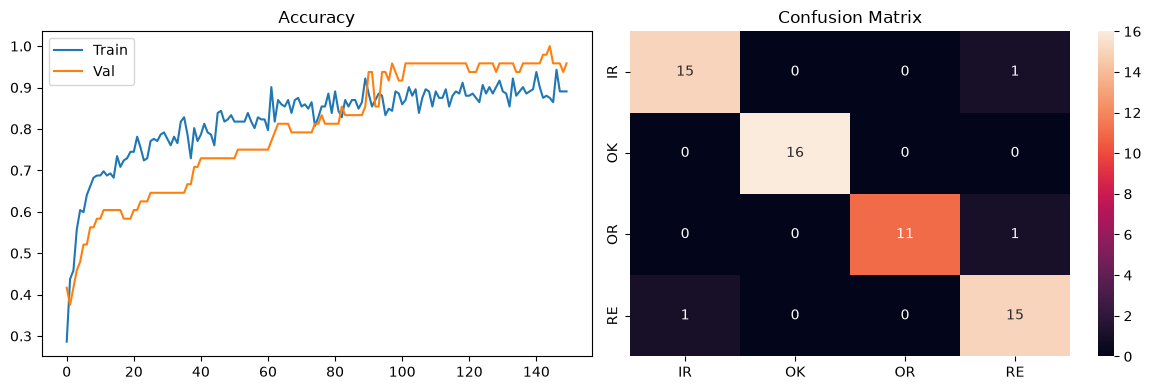

In [13]:

# ─── IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import seaborn as sns

# ─── STEP 1: LOAD DATA ─────────────────────────────────────────────────────
df = pd.read_csv('bearing_features_phase3.csv')

# Features the model receives as input
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak',
                'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']

X = df[feature_cols].values   # shape: (300, 9)
y = df['fault'].values          # shape: (300,)  e.g. ['OK','IR','OR','RE']

# ─── STEP 2: ENCODE LABELS ─────────────────────────────────────────────────
le = LabelEncoder()
y_int = le.fit_transform(y)     # OK→0, IR→1, OR→2, RE→3  (integer labels)
y_ohe = to_categorical(y_int)   # shape: (300, 4)  → one-hot vectors

num_classes = y_ohe.shape[1]   # = 4
print(f"Classes: {le.classes_}")

# ─── STEP 3: TRAIN/TEST SPLIT ──────────────────────────────────────────────
# stratify=y_int ensures each fault class has equal representation in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y_ohe, test_size=0.2, random_state=42, stratify=y_int
)
# X_train: (240, 9)   X_test: (60, 9)

# ─── STEP 4: SCALE FEATURES ────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # compute μ,σ from TRAIN only
X_test  = scaler.transform(X_test)       # apply same μ,σ to TEST (no leakage)

# ─── STEP 5: BUILD ANN ARCHITECTURE ────────────────────────────────────────
#
#  Input (9) → Dense(64) → ReLU → Dense(32) → ReLU → Dense(4) → Softmax
#
#  Why 64 neurons? Rule of thumb: ~4-8x the input size. Experiment.
#  Why 2 hidden layers? One layer can fit simple boundaries. Two captures
#  more complex fault patterns with interactions between features.
#

model = models.Sequential([
    layers.Input(shape=(9,)),               # 9 features per sample

    layers.Dense(64, activation='relu'),    # hidden layer 1: 9×64 weights + 64 biases
    layers.BatchNormalization(),              # stabilises training, speeds convergence
    layers.Dropout(0.3),                    # randomly zeros 30% of neurons → regularisation

    layers.Dense(32, activation='relu'),    # hidden layer 2: 64×32 weights + 32 biases
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(num_classes,                # output: 4 neurons (one per fault class)
                 activation='softmax')      # converts scores → probabilities summing to 1
], name='bearing_ann')

model.summary()   # prints layer-by-layer parameter count

# ─── STEP 6: COMPILE ────────────────────────────────────────────────────────
model.compile(
    optimizer='adam',                        # adaptive learning rate
    loss='categorical_crossentropy',         # multi-class cross entropy
    metrics=['accuracy']
)

# ─── STEP 7: TRAIN ──────────────────────────────────────────────────────────
# Early stopping: stop if val_loss doesn't improve for 15 epochs in a row
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,          # 32 samples per gradient update
    validation_split=0.2,   # uses 20% of training set as validation
    callbacks=[early_stop],
    verbose=1
)

# ─── STEP 8: EVALUATE ───────────────────────────────────────────────────────
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f}  |  Test Loss: {loss:.4f}")

y_pred_proba = model.predict(X_test)            # shape: (60, 4)
y_pred_int   = np.argmax(y_pred_proba, axis=1) # pick class with highest probability
y_true_int   = np.argmax(y_test, axis=1)

print(classification_report(y_true_int, y_pred_int,
      target_names=le.classes_))

# ─── STEP 9: PLOTS ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

cm = confusion_matrix(y_true_int, y_pred_int)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('ann_results.png', dpi=150)
plt.show()

Dataset shape: (300, 9)
Classes: ['IR' 'OK' 'OR' 'RE']
fault
OK    80
IR    80
RE    80
OR    60
Name: count, dtype: int64
Class mapping: {'IR': np.int64(0), 'OK': np.int64(1), 'OR': np.int64(2), 'RE': np.int64(3)}
One-hot shape: (300, 4)
Train: (240, 9), Test: (60, 9)


c:\Users\snehp\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,852 (11.14 KB)

 Trainable params: 2,852 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.2396 - loss: 1.3963 - val_accuracy: 0.2708 - val_loss: 1.3531
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3750 - loss: 1.2887 - val_accuracy: 0.5000 - val_loss: 1.2799
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4167 - loss: 1.2671 - val_accuracy: 0.5208 - val_loss: 1.2154
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4896 - loss: 1.1995 - val_accuracy: 0.5208 - val_loss: 1.1596
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5729 - loss: 1.1265 - val_accuracy: 0.6042 - val_loss: 1.1043
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5573 - loss: 1.0933 - val_accuracy: 0.6042 - val_loss: 1.0533
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6302 - loss: 1.0302 - val_accuracy: 0.5833 - val_loss: 1.0100
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6146 - loss: 0.9925 - val_accuracy: 0.6042 - val_loss

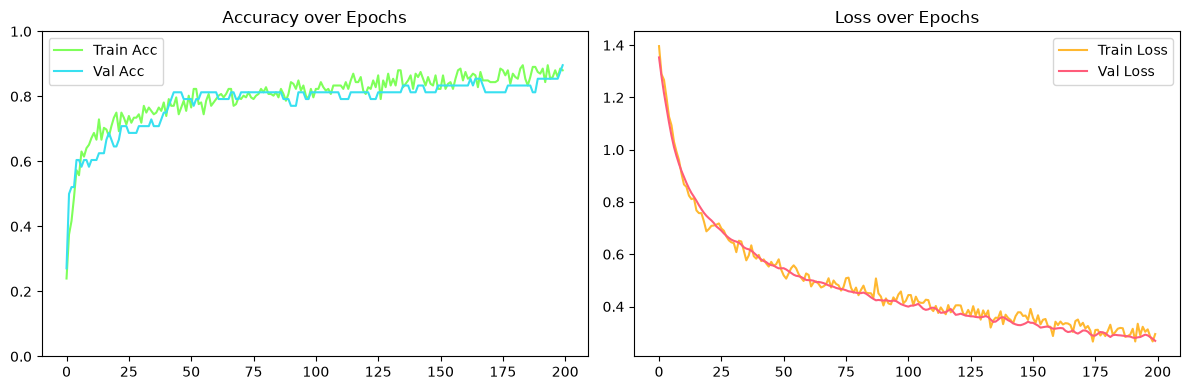

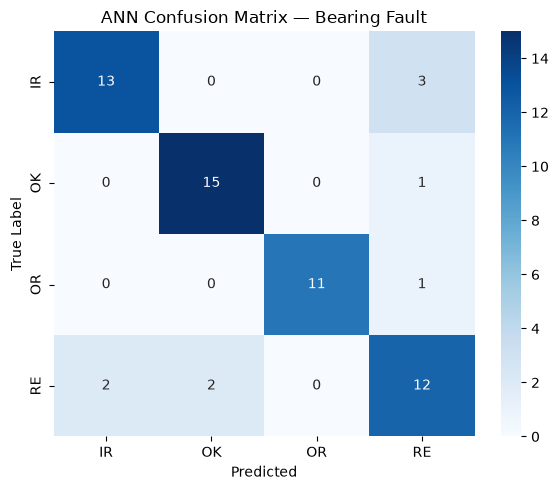

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

# ── STEP 1: LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv('bearing_features_phase3.csv')

# Feature columns — same 9 features from your Phase 3
feature_cols = ['mean', 'std', 'variance', 'rms', 'peak',
                'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']

X = df[feature_cols].values  # shape: (300, 9)
y_raw = df['fault'].values   # ['OK', 'IR', 'OR', 'RE', ...]

print(f"Dataset shape: {X.shape}")          # (300, 9)
print(f"Classes: {np.unique(y_raw)}")       # ['IR' 'OK' 'OR' 'RE']
print(df['fault'].value_counts())           # ~75 per class

# ── STEP 2: LABEL ENCODING ────────────────────────────────────────
# Convert string labels to integers: IR→1, OK→0, OR→2, RE→3
le = LabelEncoder()
y_int = le.fit_transform(y_raw)               # [0,1,2,3,...]
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
# {'IR':0, 'OK':1, 'OR':2, 'RE':3}  — alphabetical order

n_classes = len(le.classes_)                  # 4

# One-hot encode: [0,1,2,3] → [[1,0,0,0],[0,1,0,0],...]
# Required for Softmax + Categorical Cross-Entropy
y_onehot = to_categorical(y_int, num_classes=n_classes)
print(f"One-hot shape: {y_onehot.shape}")   # (300, 4)

# ── STEP 3: TRAIN-TEST SPLIT ──────────────────────────────────────
# 80/20 split, stratified to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_int     # stratify on integer labels, not one-hot
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# Train: (240, 9)  Test: (60, 9)

# ── STEP 4: STANDARDSCALER ────────────────────────────────────────
# FIT only on training data — then TRANSFORM both train and test
# If you fit on all 300 rows: data leakage (test stats contaminate model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit+transform train
X_test_scaled  = scaler.transform(X_test)       # transform only — no fit!

# After scaling: mean≈0, std≈1 for each of the 9 features
# Kurtosis: was 0.25–172, now roughly -1 to +3 (z-score)

# ── STEP 5: BUILD THE ANN ─────────────────────────────────────────
tf.random.set_seed(42)   # reproducibility

model = Sequential([
    # Input shape: (9,) — 9 features per bearing
    Dense(64, activation='relu', input_shape=(9,),
          name='hidden_1'),
    # → output: (batch, 64). Each of 64 neurons: z=W₁x+b₁, a=ReLU(z)
    # Why 64? Start with 2-4× input size. Tune via validation loss.

    Dropout(0.3, name='dropout_1'),
    # 30% of neurons randomly zeroed in each forward pass (training only)
    # Forces redundant representations → prevents memorizing 240 samples

    Dense(32, activation='relu', name='hidden_2'),
    # → output: (batch, 32). Compresses 64→32 features further.

    Dropout(0.2, name='dropout_2'),

    Dense(4, activation='softmax', name='output'),
    # → output: (batch, 4). 4 probabilities summing to 1.0
    # Softmax: ŷᵢ = e^zᵢ / Σe^zⱼ → [P(IR), P(OK), P(OR), P(RE)]
])

model.summary()
# Total trainable params: ~2,852 — tiny! RF had much more complexity.

# ── STEP 6: COMPILE ───────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # Adam: adaptive learning rate per parameter. Best default optimizer.
    # lr=0.001 is the standard starting point for Adam.

    loss='categorical_crossentropy',
    # Categorical CE for multi-class one-hot targets.
    # L = −Σ yᵢ·log(ŷᵢ) — only the true class term survives.

    metrics=['accuracy']
)

# ── STEP 7: CALLBACKS ─────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=20,           # stop if no improvement for 20 epochs
    restore_best_weights=True,  # revert to best epoch's weights
    verbose=1
)
# Equivalent to your cross-validation: prevents overfitting on 240 samples

# ── STEP 8: TRAIN ─────────────────────────────────────────────────
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,         # maximum 200 epochs (early stopping will cut this)
    batch_size=32,       # process 32 samples, then update weights once
    # 240 samples / 32 batch = 7.5 → 8 iterations per epoch
    validation_split=0.2,  # hold out 20% of train for val (48 samples)
    callbacks=[early_stop],
    verbose=1
)

# ── STEP 9: EVALUATE ──────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Predictions
y_pred_prob = model.predict(X_test_scaled)   # shape: (60, 4)
y_pred_int  = np.argmax(y_pred_prob, axis=1)  # index of max probability
y_true_int  = np.argmax(y_test, axis=1)        # recover integer from one-hot

print(classification_report(y_true_int, y_pred_int,
                             target_names=le.classes_))
# Shows precision, recall, F1 for each class — like your Phase 4

# ── STEP 10: TRAINING CURVES ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train Acc', color='#7fff5a')
ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='#38e0f0')
ax1.set_title('Accuracy over Epochs'); ax1.legend(); ax1.set_ylim(0, 1)

ax2.plot(history.history['loss'],     label='Train Loss', color='#ffb830')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='#ff5c7a')
ax2.set_title('Loss over Epochs'); ax2.legend()
plt.tight_layout(); plt.show()

# ── STEP 11: CONFUSION MATRIX ─────────────────────────────────────
cm = confusion_matrix(y_true_int, y_pred_int)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('ANN Confusion Matrix — Bearing Fault')
plt.ylabel('True Label'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

Data shape: (300, 9)
Fault distribution:
OK    80
IR    80
RE    80
OR    60
Name: count, dtype: int64

Label mapping: {'IR': 0, 'OK': 1, 'OR': 2, 'RE': 3}

Train: (240, 9)  Test: (60, 9)

Before scaling — kurtosis range: -0.04 to 259.63
After  scaling — kurtosis range: -0.73 to 6.41


c:\Users\snehp\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,852 (11.14 KB)

 Trainable params: 2,852 (11.14 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING BEGINS
Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.3542 - loss: 1.4266 - val_accuracy: 0.2708 - val_loss: 1.3300
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3750 - loss: 1.2809 - val_accuracy: 0.3333 - val_loss: 1.2467
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4531 - loss: 1.1714 - val_accuracy: 0.3958 - val_loss: 1.1903
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5677 - loss: 1.0943 - val_accuracy: 0.4375 - val_loss: 1.1556
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5312 - loss: 1.0889 - val_accuracy: 0.4583 - val_loss: 1.1289
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5365 - loss: 1.0307 - val_accuracy: 0.4792 - val_loss: 1.1037
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5833 - loss: 0.9901 - val_accuracy: 0.4792 - val_loss: 1.0800
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5781 - loss: 0.9830 - val_accuracy: 

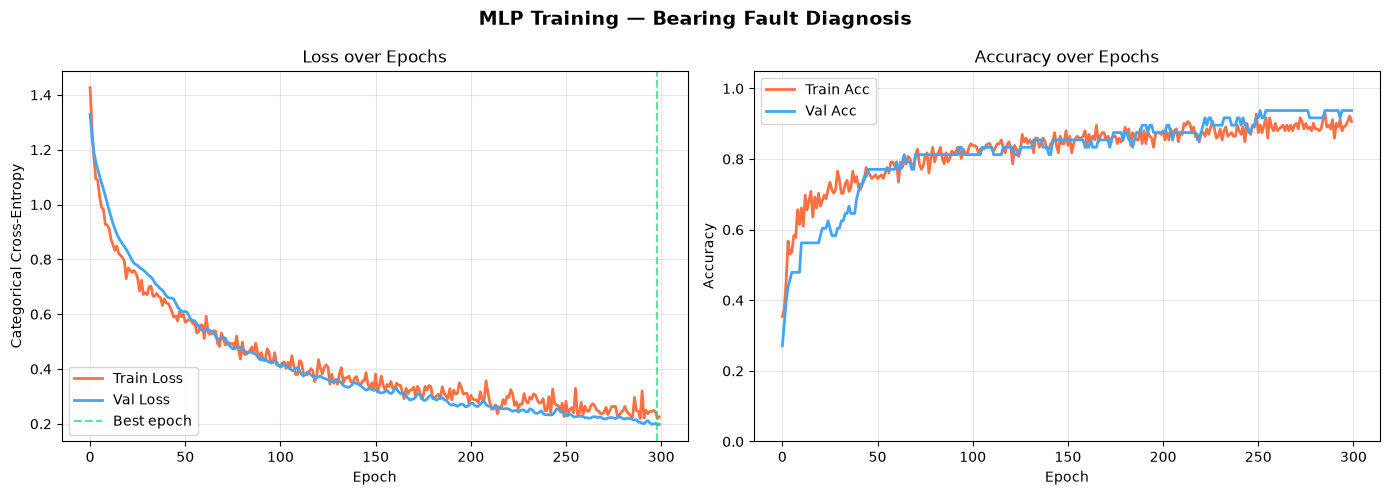

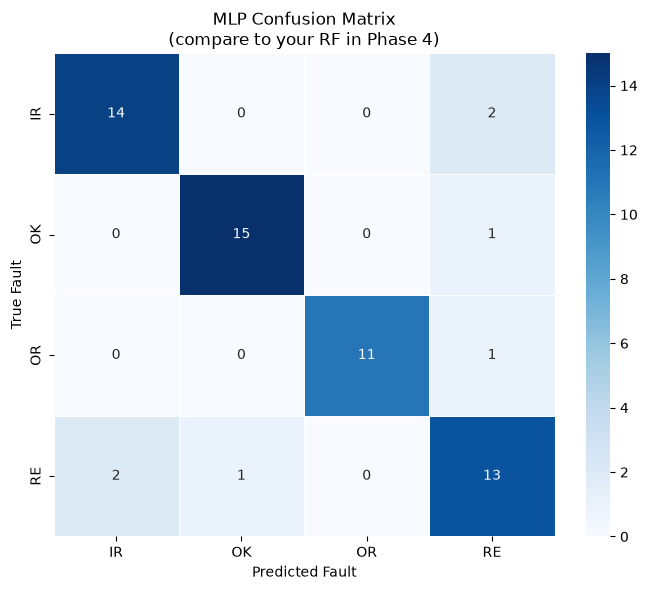


MLP Feature Weights (Layer 1) — compare to F-ratio from Phase 3:
--------------------------------------------------
  kurtosis       : ████████████████████████████████ 0.1633
  skewness       : █████████████████████████████ 0.1465
  mean           : ███████████████████████ 0.1177
  peak_to_peak   : ██████████████████████ 0.1111
  peak           : ████████████████████ 0.1004
  std            : ███████████████████ 0.0998
  crest_factor   : ██████████████████ 0.0906
  rms            : █████████████████ 0.0893
  variance       : ████████████████ 0.0814


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

# ─── STEP 1: LOAD YOUR PHASE 3 FEATURES ─────────────────────────
df = pd.read_csv('bearing_features_phase3.csv')

feature_cols = ['mean', 'std', 'variance', 'rms', 'peak',
                'peak_to_peak', 'crest_factor', 'kurtosis', 'skewness']

X = df[feature_cols].values   # shape: (300, 9)
y_raw = df['fault'].values     # ['IR', 'OK', 'OR', 'RE', ...]

print(f"Data shape: {X.shape}")
print(f"Fault distribution:\n{pd.Series(y_raw).value_counts()}")

# ─── STEP 2: ENCODE LABELS ───────────────────────────────────────
# LabelEncoder: 'IR'→0, 'OK'→1, 'OR'→2, 'RE'→3 (alphabetical)
le = LabelEncoder()
y_int = le.fit_transform(y_raw)
print(f"\nLabel mapping: {dict(zip(le.classes_, range(4)))}")

# One-hot: needed for Softmax + Categorical Cross-Entropy
# IR=[1,0,0,0]  OK=[0,1,0,0]  OR=[0,0,1,0]  RE=[0,0,0,1]
y_onehot = to_categorical(y_int, num_classes=4)

# ─── STEP 3: TRAIN-TEST SPLIT ────────────────────────────────────
# stratify=y_int ensures each split has ~25% of each fault class
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.20,         # 60 test, 240 train
    random_state=42,
    stratify=y_int          # critical: prevents all RE going to test
)
print(f"\nTrain: {X_train.shape}  Test: {X_test.shape}")

# ─── STEP 4: SCALE — FIT ON TRAIN ONLY ──────────────────────────
# Without this: kurtosis(0.25→172) dominates all weight updates
# After this: every feature has mean≈0, std≈1
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit + transform
X_test_s  = scaler.transform(X_test)       # transform only — no fit!

# Verify scaling worked
print(f"\nBefore scaling — kurtosis range: "
      f"{X_train[:,7].min():.2f} to {X_train[:,7].max():.2f}")
print(f"After  scaling — kurtosis range: "
      f"{X_train_s[:,7].min():.2f} to {X_train_s[:,7].max():.2f}")

# ─── STEP 5: BUILD THE MLP ───────────────────────────────────────
tf.random.set_seed(42)

model = Sequential([
    # Layer 1: 9 inputs → 64 neurons
    # Each neuron: z = w₁x₁ + w₂x₂ + ... + w₉x₉ + b
    # Then: output = ReLU(z) = max(0, z)
    Dense(64, activation='relu', input_shape=(9,), name='hidden_1'),

    # Dropout: during training, randomly zero 30% of 64 neurons
    # Forces network to not rely on any single neuron
    # At test time: all neurons active (but scaled by 0.7)
    Dropout(0.30, name='dropout_1'),

    # Layer 2: 64 inputs → 32 neurons
    Dense(32, activation='relu', name='hidden_2'),
    Dropout(0.20, name='dropout_2'),

    # Output: 32 inputs → 4 neurons (one per fault class)
    # Softmax converts raw scores to probabilities summing to 1.0
    Dense(4, activation='softmax', name='output'),
])

model.summary()
# Total params: 9×64+64 + 64×32+32 + 32×4+4 = 576+2080+132 = 2,788
# Compare: Random Forest has ~100 trees × ~depth decisions = millions

# ─── STEP 6: COMPILE ─────────────────────────────────────────────
model.compile(
    # Adam: adaptive learning rate per weight
    # lr=0.001 means each step moves weights by at most 0.1% of gradient
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    # Categorical CE: L = -Σ y_true * log(y_pred)
    # Works with one-hot labels + softmax output
    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# ─── STEP 7: TRAIN WITH MONITORING ───────────────────────────────
# EarlyStopping: stop if val_loss doesn't improve for 25 epochs
# restore_best_weights: revert to the BEST epoch, not the last
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

print("\n" + "="*50)
print("TRAINING BEGINS")
print("="*50)

history = model.fit(
    X_train_s, y_train,
    epochs=300,               # max epochs (early stopping will cut this)
    batch_size=32,            # 240/32 = 7.5 → 8 weight updates per epoch
    validation_split=0.20,    # hold out 48 of 240 for val (never trained on)
    callbacks=[early_stop],
    verbose=1
)

# ─── STEP 8: EVALUATE ────────────────────────────────────────────
print("\n" + "="*50)
print("EVALUATION ON HELD-OUT TEST SET (60 samples)")
print("="*50)

test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

# Get predictions
y_pred_prob = model.predict(X_test_s)          # shape: (60, 4)
y_pred_int  = np.argmax(y_pred_prob, axis=1)   # index of highest prob
y_true_int  = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_int, y_pred_int,
                             target_names=le.classes_))

# ─── STEP 9: VISUALIZE TRAINING CURVES ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP Training — Bearing Fault Diagnosis', fontsize=14, fontweight='bold')

# Loss curve
axes[0].plot(history.history['loss'],     label='Train Loss', color='#ff7043', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#42a5f5', linewidth=2)
axes[0].axvline(x=np.argmin(history.history['val_loss']),
                color='#00e676', linestyle='--', alpha=0.7, label='Best epoch')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#ff7043', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#42a5f5', linewidth=2)
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── STEP 10: CONFUSION MATRIX ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_true_int, y_pred_int)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5)
ax.set_title('MLP Confusion Matrix\n(compare to your RF in Phase 4)', fontsize=12)
ax.set_ylabel('True Fault')
ax.set_xlabel('Predicted Fault')
plt.tight_layout()
plt.show()

# ─── STEP 11: INSPECT WHAT THE NETWORK LEARNED ───────────────────
# Get weights of the first layer: shape (9, 64)
# Row i = how much feature i contributes to all 64 neurons
W1 = model.get_layer('hidden_1').get_weights()[0]  # (9, 64)
b1 = model.get_layer('hidden_1').get_weights()[1]  # (64,)

# Feature importance proxy: mean absolute weight per feature
feature_importance_mlp = np.mean(np.abs(W1), axis=1)  # (9,)
feature_importance_mlp = feature_importance_mlp / feature_importance_mlp.sum()

print("\nMLP Feature Weights (Layer 1) — compare to F-ratio from Phase 3:")
print("-" * 50)
for feat, imp in sorted(zip(feature_cols, feature_importance_mlp),
                         key=lambda x: -x[1]):
    bar = '█' * int(imp * 200)
    print(f"  {feat:15s}: {bar} {imp:.4f}")

# KEY QUESTION: Does MLP rank kurtosis #1, like your F-ratio did?

After windowing: (8700, 1024)
Train: (6960, 1024, 1), Test: (1740, 1024, 1)


c:\Users\snehp\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_1d_bearing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 1024, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 256, 64)        │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 64, 128)        │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,292 (813.64 KB)

 Trainable params: 207,844 (811.89 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.7994 - loss: 0.5259 - val_accuracy: 0.2737 - val_loss: 1.5990 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.9036 - loss: 0.2725 - val_accuracy: 0.2859 - val_loss: 3.8226 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.9375 - loss: 0.1894 - val_accuracy: 0.6659 - val_loss: 0.9754 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.9511 - loss: 0.1400 - val_accuracy: 0.8254 - val_loss: 0.4941 - learning_rate: 0.0010
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.9673 - loss: 0.0955 - val_accuracy: 0.8930 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9707 - loss: 0.0861 - val_accuracy: 0.8807 - val_loss: 0.5884 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.9698 - loss: 0.0861 - 

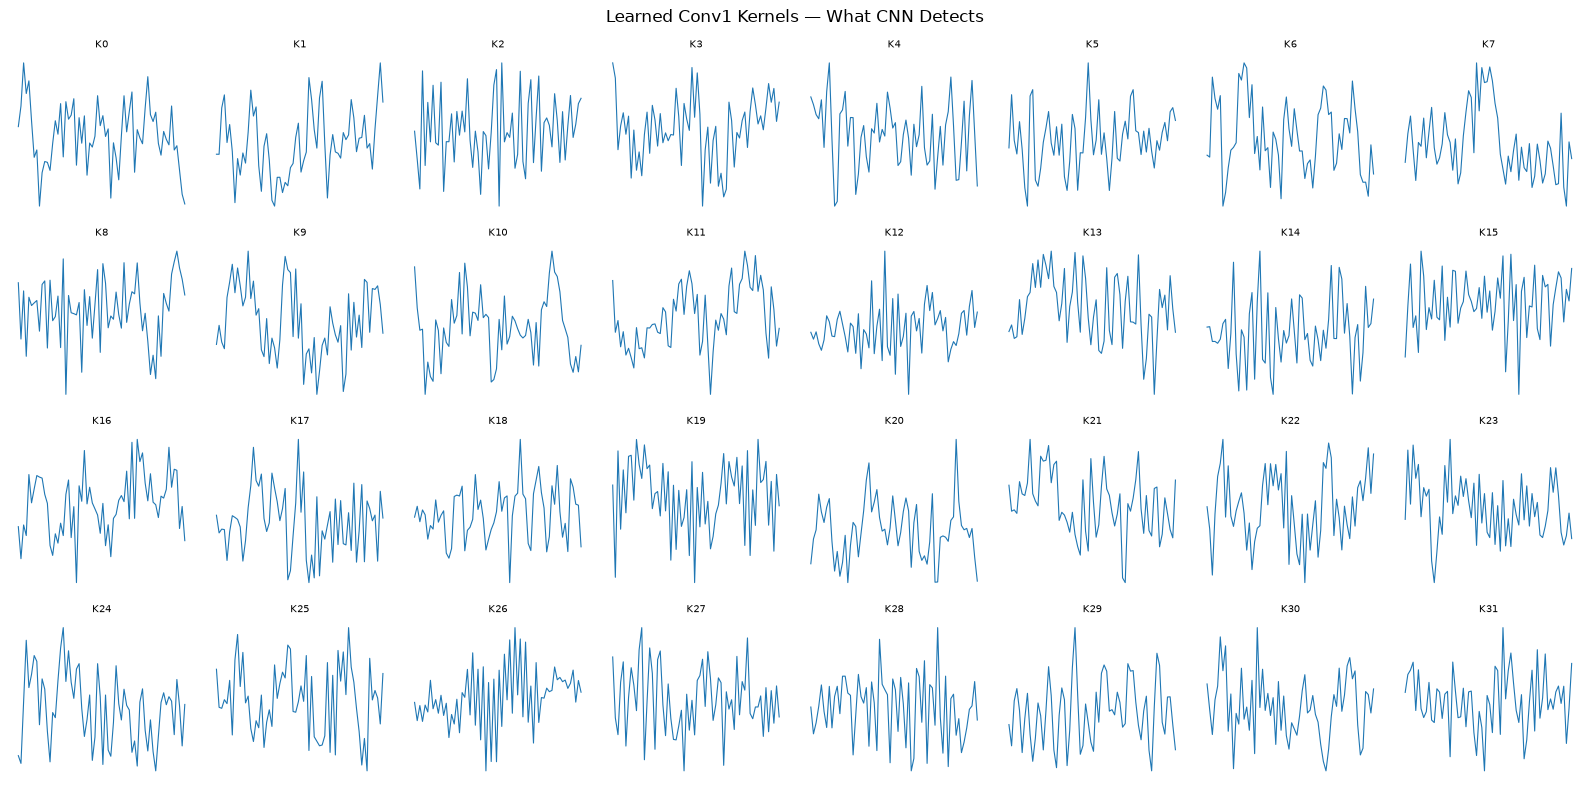

In [3]:
# ══════════════════════════════════════════════════════════════════ 
# 1D CNN FOR BEARING FAULT DIAGNOSIS 
# Input: raw vibration signals, shape (N_recordings, 15625) 
# Data augmentation: windowing to create more samples 
# ══════════════════════════════════════════════════════════════════ 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder 
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization 
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 

# ── STEP 1: LOAD RAW SIGNALS ────────────────────────────────────── 
# Assume df has columns: Data_No (1-300), Acceleration, Fault 
df_raw = pd.read_csv('data.csv') # the original 4.6M row file 
fs = 15625 # sampling frequency 

signals, labels = [], [] 
for data_no in df_raw['Data_No'].unique(): 
    segment = df_raw[df_raw['Data_No'] == data_no] 
    sig = segment['Acceleration'].values # shape: (15625, ) 
    fault = segment['Fault'].iloc[0] 
    signals.append(sig) 
    labels.append(fault) 

X_raw = np.array(signals) # shape: (300, 15625) 
y_raw = np.array(labels) 

# ── STEP 2: WINDOWING — DATA AUGMENTATION ───────────────────────── 
# Problem: 300 samples → too few for CNN 
# Solution: slide a 1024-sample window with 50% overlap 
# 300 recordings ×~29 windows=~8700 samples ! 

window_size = 1024 
hop_size = 512 # 50% overlap 
X_wins, y_wins = [], [] 

for i, (sig, label) in enumerate(zip(X_raw, y_raw)): 
    for start in range(0, len(sig) - window_size + 1, hop_size): 
        window = sig[start : start + window_size] 
        # Normalize each window to zero mean, unit variance 
        window = (window - window.mean()) / (window.std() + 1e-8) 
        X_wins.append(window) 
        y_wins.append(label) 

X_wins = np.array(X_wins) # shape: (~8700, 1024) 
y_wins = np.array(y_wins) 
print(f"After windowing: {X_wins.shape}") 

# ── STEP 3: ENCODE & SPLIT ──────────────────────────────────────── 
le = LabelEncoder() 
y_int = le.fit_transform(y_wins) 
y_onehot = to_categorical(y_int, num_classes=4) 

# Reshape for Conv1D: (N, window_size, 1) — the '1' is channels 
# Like a grayscale image has 1 channel; vibration has 1 signal 
X_wins = X_wins.reshape(-1, window_size, 1) # (N, 1024, 1) 

X_train, X_test, y_train, y_test = train_test_split(
    X_wins, y_onehot, test_size=0.2, random_state=42, stratify=y_int
) 
print(f"Train: {X_train.shape}, Test: {X_test.shape}") 
# Train: (~6960, 1024, 1) Test: (~1740, 1024, 1) 

# ── STEP 4: BUILD 1D CNN ────────────────────────────────────────── 
def build_cnn_1d(input_shape=(1024, 1), n_classes=4): 
    model = Sequential([ 
        # ── CONV BLOCK 1 ────────────────────────────────────────── 
        Conv1D(filters=32, kernel_size=64, activation='relu', padding='same', input_shape=input_shape, name='conv1'),
        # Input: (batch, 1024, 1) 
        # Output: (batch, 1024, 32) — padding='same' keeps length 
        # Kernel: (64, 1, 32) — 64-sample window × 1 channel × 32 filters 
        # Each of 32 filters learns a DIFFERENT 64-sample pattern 
        BatchNormalization(), # normalize activations → stable training 
        MaxPooling1D(pool_size=4, name='pool1'),
        # Output: (batch, 256, 32) — keeps highest activation per 4 samples 
        # MaxPool: if spike was at position 100 or 101, both detected ✓ 
        
        # ── CONV BLOCK 2 ────────────────────────────────────────── 
        Conv1D(64, kernel_size=32, activation='relu', padding='same', name='conv2'),
        # Output: (batch, 256, 64) — learns combinations of Block 1 patterns 
        BatchNormalization(),
        MaxPooling1D(4, name='pool2'),
        # Output: (batch, 64, 64) 
        
        # ── CONV BLOCK 3 ────────────────────────────────────────── 
        Conv1D(128, kernel_size=16, activation='relu', padding='same', name='conv3'),
        # Output: (batch, 64, 128) 
        BatchNormalization(),
        GlobalAveragePooling1D(name='gap'),
        # Average across ALL 64 time positions → (batch, 128) 
        # Better than Flatten (which is position-sensitive) 
        
        # ── CLASSIFIER HEAD ─────────────────────────────────────── 
        Dense(64, activation='relu', name='dense1'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax', name='output')
    ], name='cnn_1d_bearing') 
    
    return model 

cnn = build_cnn_1d(input_shape=(window_size, 1)) 
cnn.summary() 

# ── STEP 5: COMPILE AND TRAIN ───────────────────────────────────── 
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy']) 

callbacks = [ 
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)
    # ReduceLROnPlateau: halve LR if val_loss plateaus for 8 epochs 
    # Helps fine-tune near minimum — like reducing GridSearchCV step size
] 

cnn_history = cnn.fit(X_train, y_train,
                      epochs=100,
                      batch_size=64, # larger batch OK — more windows available 
                      validation_split=0.2,
                      callbacks=callbacks,
                      verbose=1) 

# ── STEP 6: EVALUATE ────────────────────────────────────────────── 
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0) 
print(f"CNN Test Accuracy: {test_acc:.4f}") 

# ── STEP 7: VISUALIZE WHAT CNN LEARNED ─────────────────────────── 
# Plot the 32 learned kernels from Conv Layer 1 
kernels = cnn.get_layer('conv1').get_weights()[0] # shape: (64, 1, 32) 
fig, axes = plt.subplots(4, 8, figsize=(16, 8)) 

for i, ax in enumerate(axes.flat): 
    ax.plot(kernels[:, 0, i], linewidth=0.8) # kernel i 
    ax.set_title(f'K{i}', fontsize=7) 
    ax.axis('off') 
    
plt.suptitle('Learned Conv1 Kernels — What CNN Detects', fontsize=12) 
plt.tight_layout()
plt.show() 
# Some kernels will look like spike detectors, some like low-pass filters 
# Compare these to your manually crafted Phase 3 features !
